# Project: CE-NBI Image Classification for Laryngeal Lesions


**Course:** B.Inf 1252 Biomedical Engineering  
**Team Members:** [Alex Schmidt , Stanislav Sauliunas , Shrabona Mukherjee]

## Project Overview
The objective of this exercise is to develop a robust machine learning pipeline to classify laryngeal lesions using a dataset of **11,144 high-magnification images**. By leveraging **Contact Endoscopy (CE)** and **Narrow Band Imaging (NBI)**, we aim to provide a digital tool that assists clinicians in distinguishing between benign and malignant tissue with high accuracy.

# Exploratory Data Analysis: CE-NBI Laryngeal Lesions Dataset

## 1. Environment Setup & Core Imports
This section initializes the essential libraries required for this project.

In [1]:
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
from PIL import Image
import scipy
from skimage.morphology import remove_small_objects
from skimage.filters import sato,frangi
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops
import networkx as nx
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score,classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
import matplotlib.pyplot as plt
import seaborn as sns
from kymatio.sklearn import Scattering2D        
from collections import defaultdict 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupShuffleSplit


%matplotlib inline

I0000 00:00:1782074907.725899  939561 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782074907.788499  939561 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782074912.060241  939561 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
from grakel import Graph
from grakel.kernels import WeisfeilerLehman, VertexHistogram, EdgeHistogram

## 2. Hierarchical Dataset Parser
Medical image datasets are typically stored in nested directory architectures. This function automatically crawls through 5 levels of folders: **Split $\rightarrow$ Binary Label $\rightarrow$ Histopathology Condition $\rightarrow$ Patient ID $\rightarrow$ Raw Images**. It safely captures file locations and logs the metadata into a single searchable spreadsheet (DataFrame).

In [7]:
# This function crawls through the unzipped nested directories to automatically 
# discover files, capture hierarchical labels, and map patient IDs.

def parse_dataset(root_dir):
    """
    Crawls a structured CE-NBI dataset directory and aggregates 
    file metadata into a pandas DataFrame.
    """
    records = []

    # Iteration Level 1: Target Dataset Splits
    for split in ["Training", "Testing"]:
        split_path = root_dir / split
        if not split_path.exists():
            continue

        # Iteration Level 2: Target Binary Classification Labels
        for label in ["Benign", "Malignant"]:
            label_path = split_path / label
            if not label_path.exists():
                continue

            # Iteration Level 3: Extract Specific Histopathology Conditions (e.g., Polyp, SCC)
            for condition in os.listdir(label_path):
                condition_path = label_path / condition
                if not condition_path.is_dir():
                    continue

                # Iteration Level 4: Extract Patient IDs to ensure patient-independent evaluation
                for patient in os.listdir(condition_path):
                    patient_path = condition_path / patient
                    if not patient_path.is_dir():
                        continue

                        # Iteration Level 5: Isolate raw medical image files
                    for img_name in os.listdir(patient_path):
                        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                            # Append structural metadata mapping to the database basket
                            records.append({
                                "split": split,
                                "label": label,
                                "condition": condition,
                                "patient_id": patient,
                                "image_path": str(patient_path / img_name)
                            })

    # Convert compiled metadata list into a structured DataFrame spreadsheet
    return pd.DataFrame(records)

# Create a dataframe
UNPACKED_DIR = Path("CE-NBI_Dataset_Unpacked/CE-NBI_Dataset")
df = parse_dataset(UNPACKED_DIR)



In [3]:
df.head()

,split,label,condition,patient_id,image_path
0,Training,Benign,Low_grade_dysplasia,Patient002,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...
1,Training,Benign,Low_grade_dysplasia,Patient002,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...
2,Training,Benign,Low_grade_dysplasia,Patient002,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...
3,Training,Benign,Low_grade_dysplasia,Patient002,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...
4,Training,Benign,Low_grade_dysplasia,Patient002,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...


In [4]:

df.tail()

,split,label,condition,patient_id,image_path
8392,Testing,Malignant,SCC,Patient202,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...
8393,Testing,Malignant,SCC,Patient202,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...
8394,Testing,Malignant,SCC,Patient202,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...
8395,Testing,Malignant,SCC,Patient202,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...
8396,Testing,Malignant,SCC,Patient202,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...


## 3. Spreadsheet Check & Binary Distribution
Before exploring granular details, we review the top of the spreadsheet and analyze the total volume of **Benign** vs. **Malignant** categories to check baseline balance.

In [5]:
# Verify dataframe structure and total image count
print("--- DataFrame Preview ---")
print(df.head())
print("\nTotal Images:", len(df))
print("Columns:", df.columns.tolist())

# Analyze binary class distribution
print("\n=== Class Distribution ===")
print(df["label"].value_counts())

# Verify training/testing partition balance
print("\n=== Split Distribution ===")
print(df.groupby(["split", "label"]).size())

--- DataFrame Preview ---
      split   label            condition  patient_id  \
0  Training  Benign  Low_grade_dysplasia  Patient002   
1  Training  Benign  Low_grade_dysplasia  Patient002   
2  Training  Benign  Low_grade_dysplasia  Patient002   
3  Training  Benign  Low_grade_dysplasia  Patient002   
4  Training  Benign  Low_grade_dysplasia  Patient002   

                                          image_path  
0  CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...  
1  CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...  
2  CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...  
3  CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...  
4  CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...  

Total Images: 8397
Columns: ['split', 'label', 'condition', 'patient_id', 'image_path']

=== Class Distribution ===
label
Benign       4910
Malignant    3487
Name: count, dtype: int64

=== Split Distribution ===
split     label    
Testing   Benign        874
          Malignant     987
Training  Benign  

## 4. Patient Independence & Image Volume Tracking
To prevent medical data leakage during model training, images belonging to a single human subject must not be split across training and testing sets. This block tracks how many unique patients exist and profiles the statistical distribution of images harvested per individual.


=== Unique Patients per Split ===
split
Testing      34
Training    115
Name: patient_id, dtype: int64

=== Images per Patient ===
count    149.000000
mean      59.268456
std       37.126269
min        2.000000
25%       30.000000
50%       57.000000
75%       80.000000
max      186.000000
dtype: float64


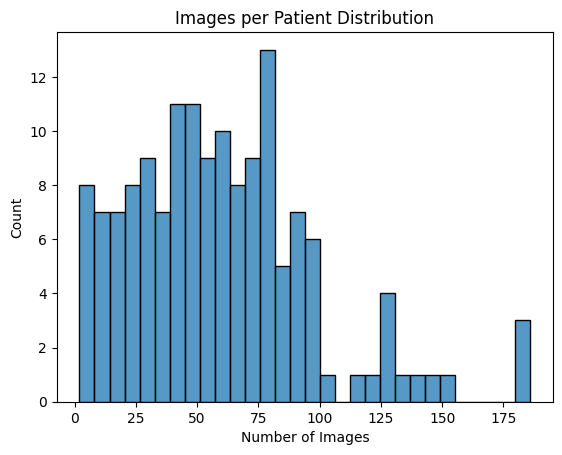

In [7]:
patients_per_split = df.groupby("split")["patient_id"].nunique()
print("\n=== Unique Patients per Split ===")
print(patients_per_split)

images_per_patient = df.groupby("patient_id").size()

print("\n=== Images per Patient ===")
print(images_per_patient.describe())

sns.histplot(images_per_patient, bins=30)
plt.title("Images per Patient Distribution")
plt.xlabel("Number of Images")
plt.show()

## 5. Level 2 Histopathology Condition Distribution
Medical datasets are naturally prone to **Data Imbalance** because certain conditions are clinically more prevalent than others. This cell visualizes the distribution across all 6 specific pathologies, sorted cleanly from lowest count to highest count.


=== Condition Distribution ===
condition
Reinkes_edema           2661
SCC                     1906
Low_grade_dysplasia     1428
High_grade_dysplasia    1039
Polyp                    821
Carcinoma_in_situ        542
Reinke's_edema           434
Name: count, dtype: int64


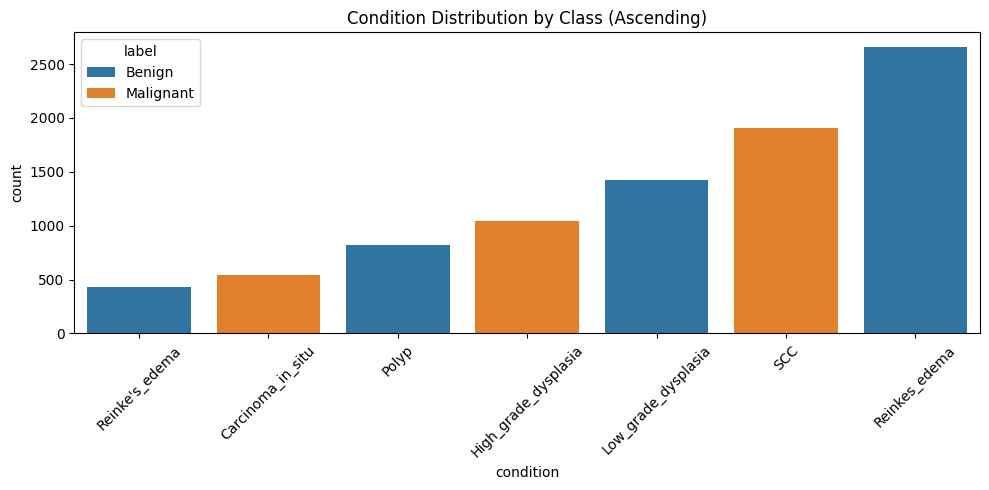

In [8]:
print("\n=== Condition Distribution ===")

condition_order = (
    df["condition"]
    .value_counts(ascending=True)
    .index
)

print(df["condition"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="condition",
    hue="label",
    order=condition_order
)

plt.xticks(rotation=45)
plt.title("Condition Distribution by Class (Ascending)")
plt.tight_layout()
plt.show()

## 6. Spatial Attribute Analysis (Image Dimensions)
Deep Learning networks process image pixels using fixed matrix grids (typically $224 \times 224$). This block sweeps the image files programmatically to inspect width and height variations, defining our explicit resizing requirements for the upcoming preprocessing steps.

In [3]:
def get_image_sizes(sample_paths):
    sizes = []
    for p in sample_paths:
        try:
            with Image.open(p) as img:
                sizes.append(img.size)
        except:
            continue
    return sizes

sizes = get_image_sizes(df["image_path"].tolist())

if sizes:
    widths, heights = zip(*sizes)
    print("\n=== Image Size Stats ===")
    print("Width:", pd.Series(widths).describe())
    print("Height:", pd.Series(heights).describe())


=== Image Size Stats ===
Width: count    8831.000000
mean     1271.382176
std       308.654583
min       720.000000
25%      1280.000000
50%      1280.000000
75%      1280.000000
max      1842.000000
dtype: float64
Height: count    8831.000000
mean      918.226248
std       203.870478
min       540.000000
25%      1008.000000
50%      1008.000000
75%      1008.000000
max      1080.000000
dtype: float64


## 7. Image Preprocessing & Vascular Enhancement

### 7.1 Contrast Modification
Raw endoscopic images are subjected to green-channel extraction to maximize hemoglobin contrast, followed by an OpenCV Morphological Top-Hat elliptical filter kernel (`cv2.MORPH_TOPHAT`) to even out irregular background lighting and illumination artifacts.We apply different filters.

### 7.2 Vascular Segmentation & Skeletonization
To isolate vessel geometries, we apply a multi-scale **Sato Vesselness Filter** to emphasize tubular vascular contours. The resulting segmented masks are skeletonized to single-pixel widths using morphological thinning, exposing the core topological network structure of the laryngeal sub-epithelial blood vessels.

In [8]:
def preprocess_image(image_path):
    """
    Takes a raw image path, loads it, and prepares it for vessel analysis.
    Returns the original image, the green channel, and the enhanced/cleaned channel.
    """
    # Step 1: Read the image
    img = cv2.imread(str(image_path))

    # Step 2: Convert from BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Step 3: Resize to standard size
    img_resized = cv2.resize(img_rgb, (128, 128))

    # Step 4: Extract green channel
    green_channel = img_resized[:, :, 1]

    # Step 5: Invert the green channel
    inverted = 255 - green_channel

    # Step 6: Remove uneven background lighting
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    tophat = cv2.morphologyEx(inverted, cv2.MORPH_TOPHAT, kernel)

    # Step 7: Normalize to 0.0 - 1.0 range
    normalized = tophat.astype(np.float32) / 255.0

    return img_resized, green_channel, normalized

Testing on Benign image...


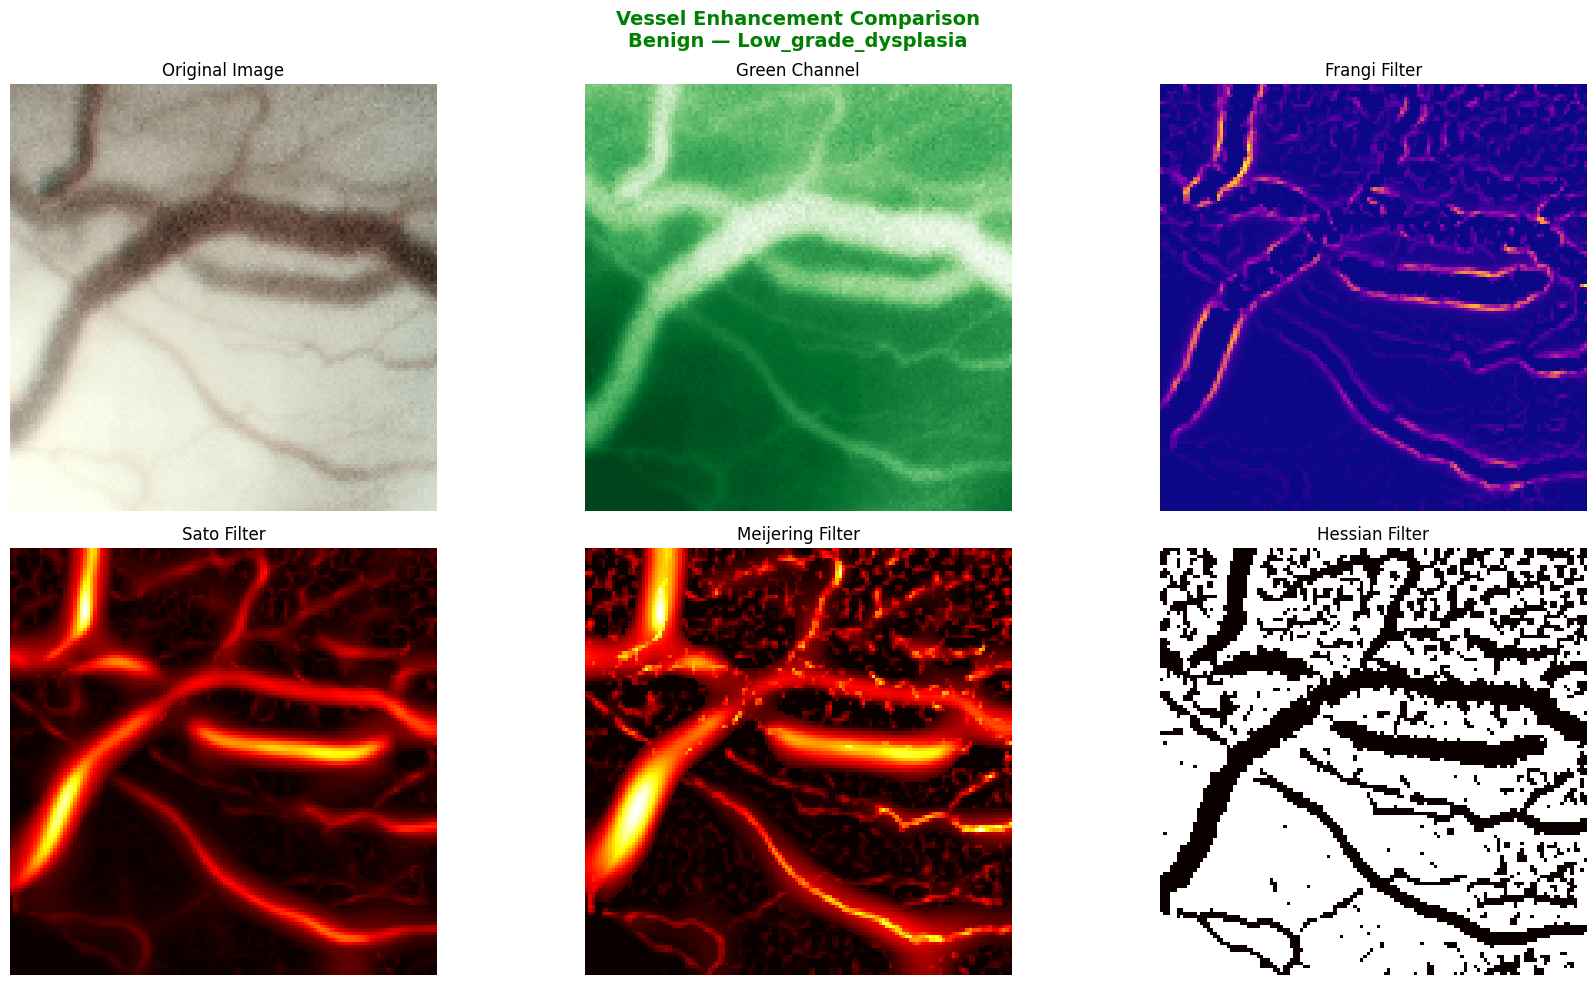

Testing on Malignant image...


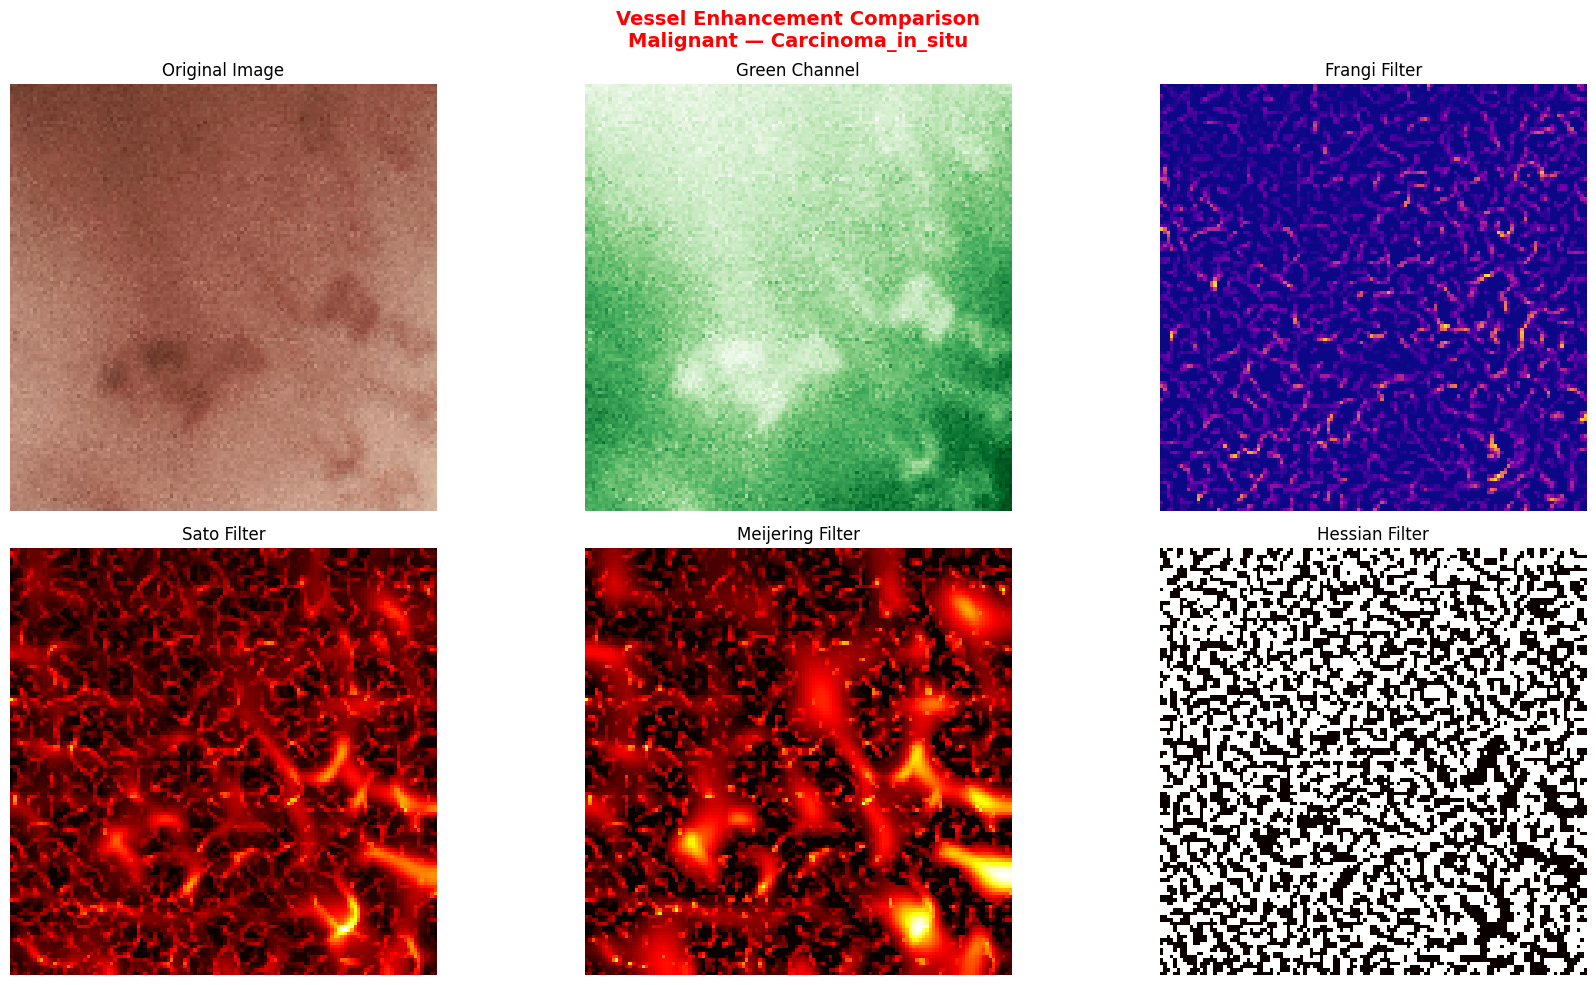

In [23]:
def apply_vessel_filters(normalized_channel):
    """
    Applies 4 different vessel enhancement filters to the same image.
    Returns all 4 results for comparison.
    """
    # Filter 1: Frangi
    frangi_result = frangi(
        normalized_channel,
        sigmas=range(1, 9),
        alpha=0.5,
        beta=0.5,
        black_ridges=True
    )

    # Filter 2: Sato
    from skimage.filters import sato
    sato_result = sato(
        normalized_channel,
        sigmas=range(1, 9),
        black_ridges=False
    )

    # Filter 3: Meijering
    from skimage.filters import meijering
    meijering_result = meijering(
        normalized_channel,
        sigmas=range(1, 9),
        black_ridges=False
    )

    # Filter 4: Hessian
    from skimage.filters import hessian
    hessian_result = hessian(
        normalized_channel,
        sigmas=range(1, 9),
        black_ridges=False
    )

    return frangi_result, sato_result, meijering_result, hessian_result


def visualize_filters(image_path, label, condition):
    """
    Runs the full preprocessing + all 4 filters on one image
    and shows everything side by side.
    """
    # Preprocess
    img_rgb, green_channel, normalized = preprocess_image(image_path)

    # Apply filters
    frangi_r, sato_r, meijering_r, hessian_r = apply_vessel_filters(normalized)

    # Plot everything
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Flatten axes for easy indexing
    ax = axes.ravel()

    # Plot 1: Original image
    ax[0].imshow(img_rgb)
    ax[0].set_title("Original Image", fontsize=12)
    ax[0].axis("off")

    # Plot 2: Green channel
    ax[1].imshow(green_channel, cmap="Greens")
    ax[1].set_title("Green Channel", fontsize=12)
    ax[1].axis("off")

    # Plot 3: Frangi
    ax[2].imshow(frangi_r, cmap="plasma")
    ax[2].set_title("Frangi Filter", fontsize=12)
    ax[2].axis("off")

    # Plot 4: Sato
    ax[3].imshow(sato_r, cmap="hot")
    ax[3].set_title("Sato Filter", fontsize=12)
    ax[3].axis("off")

    # Plot 5: Meijering
    ax[4].imshow(meijering_r, cmap="hot")
    ax[4].set_title("Meijering Filter", fontsize=12)
    ax[4].axis("off")

    # Plot 6: Hessian
    ax[5].imshow(hessian_r, cmap="hot")
    ax[5].set_title("Hessian Filter", fontsize=12)
    ax[5].axis("off")

    # Add overall title showing which class this image is from
    fig.suptitle(f"Vessel Enhancement Comparison\n{label} — {condition}",
                fontsize=14, fontweight="bold",
                color="green" if label == "Benign" else "red")

    plt.tight_layout()
    plt.show()


# Test on one benign and one malignant image
benign_sample = df[df["label"] == "Benign"]["image_path"].iloc[0]
malignant_sample = df[df["label"] == "Malignant"]["image_path"].iloc[0]

benign_condition = df[df["label"] == "Benign"]["condition"].iloc[0]
malignant_condition = df[df["label"] == "Malignant"]["condition"].iloc[0]

print("Testing on Benign image...")
visualize_filters(benign_sample, "Benign", benign_condition)

print("Testing on Malignant image...")
visualize_filters(malignant_sample, "Malignant", malignant_condition)

Benign Pipeline:


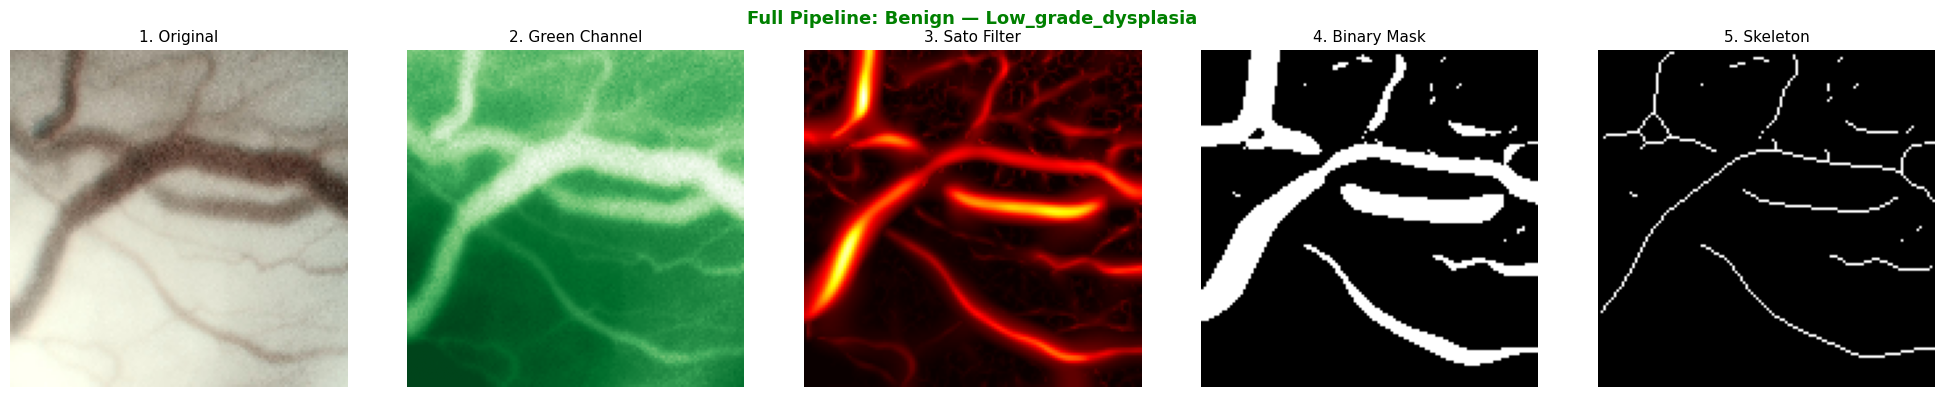

Malignant Pipeline:


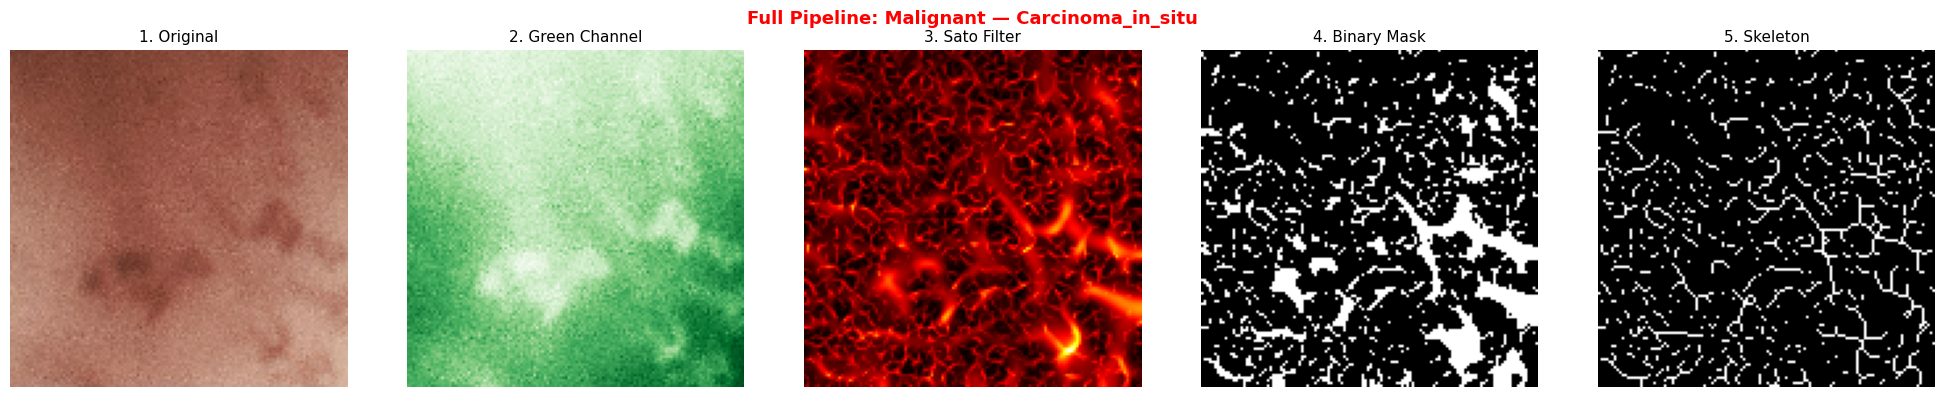

In [24]:
def get_skeleton(filter_result, percentile=80):
    """
    Takes a filter result and converts it to a binary mask
    then skeletonizes it down to 1 pixel wide vessel paths.
    Returns both the binary mask and the skeleton.
    """
    # Step 1: Threshold — keep only the top X% strongest vessel responses
    threshold = np.percentile(filter_result, percentile)

    # Step 2: Create binary mask — True where vessel, False where background
    binary_mask = filter_result > threshold

    # Step 3: Skeletonize
    skeleton = skeletonize(binary_mask)

    return binary_mask, skeleton


def visualize_skeleton(image_path, label, condition):
    """
    Shows the full pipeline for one image:
    Original → Green Channel → Filter → Binary Mask → Skeleton
    """
    # Preprocess
    img_rgb, green_channel, normalized = preprocess_image(image_path)

    # Apply filter
    _, sato_r, _, _ = apply_vessel_filters(normalized)

    # Get skeleton
    binary_mask, skeleton = get_skeleton(sato_r)

    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    ax = axes.ravel()

    ax[0].imshow(img_rgb)
    ax[0].set_title("1. Original", fontsize=11)
    ax[0].axis("off")

    ax[1].imshow(green_channel, cmap="Greens")
    ax[1].set_title("2. Green Channel", fontsize=11)
    ax[1].axis("off")

    ax[2].imshow(sato_r, cmap="hot")
    ax[2].set_title("3. Sato Filter", fontsize=11)
    ax[2].axis("off")

    ax[3].imshow(binary_mask, cmap="gray")
    ax[3].set_title("4. Binary Mask", fontsize=11)
    ax[3].axis("off")

    ax[4].imshow(skeleton, cmap="gray")
    ax[4].set_title("5. Skeleton", fontsize=11)
    ax[4].axis("off")

    fig.suptitle(f"Full Pipeline: {label} — {condition}",
                fontsize=13, fontweight="bold",
                color="green" if label == "Benign" else "red")

    plt.tight_layout()
    plt.show()


# Test on one benign and one malignant
print("Benign Pipeline:")
visualize_skeleton(benign_sample, "Benign", benign_condition)

print("Malignant Pipeline:")
visualize_skeleton(malignant_sample, "Malignant", malignant_condition)

In [17]:
benign_sample='CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Training/Benign/Low_grade_dysplasia/Patient002/P002 (1).jpg'

## 8. Downstream Traditional Machine Learning Evaluation
### 8.1 Comparative Benchmarking of Classifiers (SVM, Trees, and Linear Models)

We train and evaluate a diverse family of machine learning classifiers on raw pixel data. We explicitly benchmark four distinct algorithmic approaches:

1. **Support Vector Machine (SVM / SVC):** Maps our handcrafted features into a higher-dimensional space using a Radial Basis Function (RBF) kernel to establish optimal, non-linear margin decision boundaries.
2. **Logistic Regression (L2 Regularized):** Serves as a parametric baseline model utilizing regularized maximum-likelihood estimation to evaluate the linear separability of our vascular markers.
3. **Random Forest Classifier:** An ensemble tree-based algorithm that evaluates complex, non-linear threshold interactions across bagging subsets of our structural data.
4. **XGBoost (Extreme Gradient Boosting):** Implements sequential gradient-boosted decision trees optimized via a regularized objective function to minimize classification loss on minor class variations.

To ensure class-proportional penalization, all algorithms incorporate data-balancing configurations (`class_weight='balanced'`) to handle the uneven sample distributions across our benign and malignant lesion categories.

In [4]:
# 1. Load the saved separate feature sheets
train_data_raw = pd.read_csv("train_features.csv")
test_data = pd.read_csv("test_features.csv")

train_data_raw['patient_id'] = train_data_raw['image_path'].apply(lambda x: x.split(os.sep)[-2])
test_data['patient_id'] = test_data['image_path'].apply(lambda x: x.split(os.sep)[-2])

# Extract unique patient IDs from the raw training sheet
unique_train_patients = train_data_raw['patient_id'].unique()

# Shuffle patients randomly with a fixed seed so it's reproducible
np.random.seed(42)
unique_train_patients = np.array(unique_train_patients)
np.random.shuffle(unique_train_patients)

# Calculate 80% split point for validation
split_idx = int(len(unique_train_patients) * 0.8)

# Group patient IDs into Train and Validation set
train_patients = unique_train_patients[:split_idx]
val_patients = unique_train_patients[split_idx:]

# Filter the raw dataframe into clean Train and Validation dataframes
train_data = train_data_raw[train_data_raw['patient_id'].isin(train_patients)].copy()
val_data = train_data_raw[train_data_raw['patient_id'].isin(val_patients)].copy()
 
# Isolate feature columns 
# (Added 'condition' and 'patient_id' to exclude so they don't accidentally get scaled)
exclude_cols = ['image_path', 'label', 'split', 'condition', 'patient_id']
feature_cols = [col for col in train_data.columns if col not in exclude_cols]

# Create X (features) and y (diagnostic targets) for all three sets
X_train = train_data[feature_cols]
y_train = train_data['label']

X_val = val_data[feature_cols]
y_val = val_data['label']

X_test = test_data[feature_cols]
y_test = test_data['label']

# Scale feautures
scaler = StandardScaler()

# 1. ONLY fit and transform on the pure training subset
X_train_scaled = scaler.fit_transform(X_train)

# 2. ONLY transform validation and testing subsets using the training rules
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print(f"Training shapes:   {X_train_scaled.shape}")
print(f"Validation shapes: {X_val_scaled.shape}")
print(f"Testing shapes:    {X_test_scaled.shape}")

Training shapes:   (5325, 62)
Validation shapes: (1211, 62)
Testing shapes:    (1861, 62)


In [16]:
# 1. Initialize Random Forest with automated class weighting
rf_model = RandomForestClassifier(
   n_estimators=300,       # Increase trees
    max_depth=12,           # Allow deeper feature combinations
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

# 2. Initialize Support Vector Machine (SVM) with automated class weighting
svm_model = SVC(
    kernel='rbf', 
    class_weight='balanced', 
    probability=True, 
    random_state=42
)

# 3. Train both models on your scaled training data
print("Training Random Forest Classifier...")
rf_model.fit(X_train_scaled, y_train)

print("Training Support Vector Machine...")
svm_model.fit(X_train_scaled, y_train)

print("Both models trained successfully!")

Training Random Forest Classifier...
Training Support Vector Machine...
Both models trained successfully!



=================== Random Forest (Balanced) EVALUATION ===================
              precision    recall  f1-score   support

      Benign       0.57      0.82      0.67       874
   Malignant       0.74      0.46      0.57       987

    accuracy                           0.63      1861
   macro avg       0.66      0.64      0.62      1861
weighted avg       0.66      0.63      0.62      1861



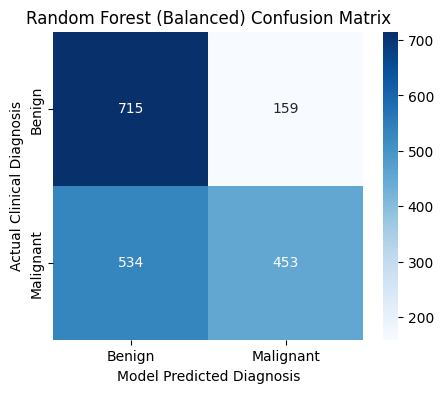


=================== SVM (Balanced) EVALUATION ===================
              precision    recall  f1-score   support

      Benign       0.61      0.66      0.64       874
   Malignant       0.68      0.63      0.65       987

    accuracy                           0.65      1861
   macro avg       0.65      0.65      0.65      1861
weighted avg       0.65      0.65      0.65      1861



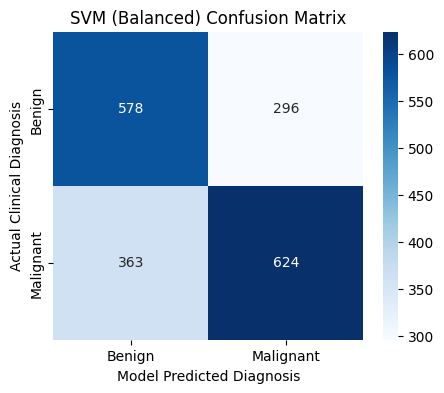

In [17]:
def evaluate_clinical_model(model, X_test, y_test, model_name):
    # Predict classes
    y_pred = model.predict(X_test)
    
    print(f"\n=================== {model_name} EVALUATION ===================")
    print(classification_report(y_test, y_pred))
    
    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=["Benign", "Malignant"])
    
    # Plot the matrix visually
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["Benign", "Malignant"], 
                yticklabels=["Benign", "Malignant"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Clinical Diagnosis")
    plt.xlabel("Model Predicted Diagnosis")
    plt.show()

# Run evaluation for both models
evaluate_clinical_model(rf_model, X_test_scaled, y_test, "Random Forest (Balanced)")
evaluate_clinical_model(svm_model, X_test_scaled, y_test, "SVM (Balanced)")


=================== Gradient Boosting EVALUATION ===================
              precision    recall  f1-score   support

      Benign       0.57      0.84      0.68       874
   Malignant       0.76      0.44      0.56       987

    accuracy                           0.63      1861
   macro avg       0.67      0.64      0.62      1861
weighted avg       0.67      0.63      0.62      1861



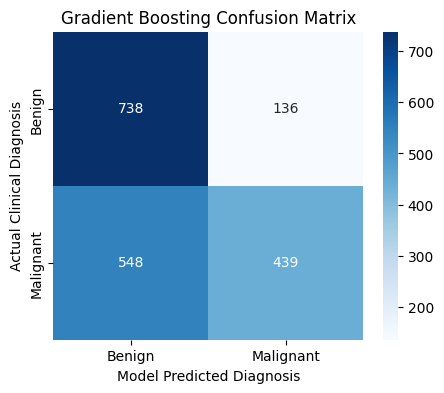

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

# Evaluate
evaluate_clinical_model(gb_model, X_test_scaled, y_test, "Gradient Boosting")


=================== Logistic Regression (Balanced) EVALUATION ===================
              precision    recall  f1-score   support

      Benign       0.59      0.69      0.63       874
   Malignant       0.67      0.58      0.62       987

    accuracy                           0.63      1861
   macro avg       0.63      0.63      0.63      1861
weighted avg       0.63      0.63      0.63      1861



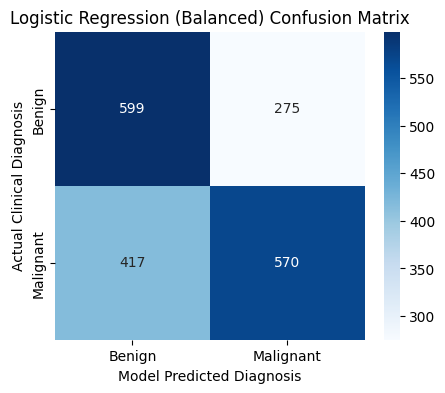

In [19]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression with balanced weights
log_model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42
)
log_model.fit(X_train_scaled, y_train)

# Evaluate
evaluate_clinical_model(log_model, X_test_scaled, y_test, "Logistic Regression (Balanced)")

## 9. Morphological & Geometric Feature Extraction

To capture vascular alterations associated with tumor angiogenesis (neo-vascularization), we extract four specialized quantitative biomarkers from the skeletonized vascular graphs using `skimage`:
* **Vessel Density:** The ratio of blood vessel pixels to total tissue background.
* **Skeleton Length:** The cumulative length of all extracted vascular networks.
* **Branch Count ($N$-Branches):** Total bifurcation points within the vascular tree structure.
* **Mean Tortuosity:** The degree of vessel twisting and curvature, capturing abnormal malignant growth patterns.

In [27]:
 def extract_vessel_features(image_path):
    """
    Optimized pipeline running at maximum CPU capacity.
    """
    # Step 1: Preprocess
    img_rgb, green_channel, normalized = preprocess_image(image_path)

    # Step 2: Sato filter
    sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)

    # Step 3: Get binary mask and skeleton
    binary_mask, skeleton = get_skeleton(sato_r)

    # Convert skeleton to boolean for morphology operations
    skeleton_bool = skeleton > 0

    # Melt away tiny disjointed noise fragments before Skan looks at it.
    clean_skeleton = remove_small_objects(skeleton_bool, min_size=10)

    # Total metrics based on clean morphology
    total_vessel_pixels = np.sum(binary_mask)
    vessel_density = total_vessel_pixels / (128 * 128)
    skeleton_length = np.sum(clean_skeleton)

    features = {
        "vessel_density": vessel_density,
        "skeleton_length": skeleton_length,
        "total_vessel_pixels": total_vessel_pixels,
    }

    try:
        # Skan now processes a clean, continuous network instantly
        sk = Skeleton(clean_skeleton)
        branch_data = summarize(sk)

        features["n_branches"] = len(branch_data)
        features["mean_branch_length"] = branch_data["branch-distance"].mean()
        features["total_branch_length"] = branch_data["branch-distance"].sum()

        # Tortuosity calculation
        branch_data["tortuosity"] = (
            branch_data["branch-distance"] /
            (branch_data["euclidean-distance"] + 1e-6)
        )
        features["mean_tortuosity"] = branch_data["tortuosity"].mean()
        features["max_tortuosity"] = branch_data["tortuosity"].max()

        # Angle calculation
        branch_data["angle"] = np.degrees(
            np.arctan2(
                branch_data["coord-dst-1"] - branch_data["coord-src-1"],
                branch_data["coord-dst-0"] - branch_data["coord-src-0"]
            )
        )
        features["mean_angle"] = branch_data["angle"].mean()
        features["std_angle"] = branch_data["angle"].std()

    except Exception as e:
        # Fallbacks for empty networks
        features["n_branches"] = 0
        features["mean_branch_length"] = 0
        features["total_branch_length"] = 0
        features["mean_tortuosity"] = 0
        features["max_tortuosity"] = 0
        features["mean_angle"] = 0
        features["std_angle"] = 0

    # Regionprops block
    try:
        labeled_mask = label(binary_mask)
        props = regionprops(labeled_mask)

        if props:
            areas = [p.area for p in props]
            perimeters = [p.perimeter for p in props]
            thicknesses = [a/p for a, p in zip(areas, perimeters) if p > 0]

            features["mean_thickness"] = np.mean(thicknesses)
            features["n_vessel_segments"] = len(props)
        else:
            features["mean_thickness"] = 0
            features["n_vessel_segments"] = 0
    except:
        features["mean_thickness"] = 0
        features["n_vessel_segments"] = 0

    return features

In [28]:
# Test the optimized function on a single image sample
# Make sure 'benign_sample' contains your local or unzipped image path string


try:
    test_img = train_data["image_path"].iloc[0]
    test_features = extract_vessel_features(test_img)
    
    print("\n" + "="*35)
    print("OPTIMIZED FEATURES FOR ONE IMAGE")
    print("="*35)
    for feature_name, value in test_features.items():
        print(f"{feature_name:<25} : {value:.4f}")
    print("="*35)

except NameError:
    print("Error: 'test_img' is not defined. Please pass a valid path string.")
except Exception as e:
    print(f"Extraction failed: {e}")


OPTIMIZED FEATURES FOR ONE IMAGE
vessel_density            : 0.2000
skeleton_length           : 80.0000
total_vessel_pixels       : 3277.0000
n_branches                : 0.0000
mean_branch_length        : 0.0000
total_branch_length       : 0.0000
mean_tortuosity           : 0.0000
max_tortuosity            : 0.0000
mean_angle                : 0.0000
std_angle                 : 0.0000
mean_thickness            : 1.5272
n_vessel_segments         : 21.0000


/local/jobs/u28600_14404722/ipykernel_810778/237562312.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean_skeleton = remove_small_objects(skeleton_bool, min_size=10)


In [29]:
def extract_vessel_features(image_path):
    """
    Upgraded feature extraction — extracts full distributions
    instead of just means. Gives 35+ features per image.
    """
    # ── Same pipeline as before ──
    img_rgb, green_channel, normalized = preprocess_image(image_path)
    sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)
    binary_mask, skeleton = get_skeleton(sato_r)
    skeleton_bool = skeleton > 0
    clean_skeleton = remove_small_objects(skeleton_bool, min_size=10)

    # ── Basic features (same as before) ──
    total_vessel_pixels = int(np.sum(binary_mask))
    vessel_density = total_vessel_pixels / (128 * 128)
    skeleton_length = int(np.sum(clean_skeleton))

    features = {
        "vessel_density":      vessel_density,
        "skeleton_length":     skeleton_length,
        "total_vessel_pixels": total_vessel_pixels,
    }

    # ── Helper function to extract distribution stats ──
    def dist_stats(arr, prefix):
        """
        Given a numpy array and a name prefix,
        returns 7 statistical features as a dictionary.
        """
        arr = np.array(arr)
        if len(arr) == 0:
            # If empty, return zeros for all 7 stats
            return {
                f"{prefix}_mean": 0, f"{prefix}_std":  0,
                f"{prefix}_min":  0, f"{prefix}_max":  0,
                f"{prefix}_p25":  0, f"{prefix}_p75":  0,
                f"{prefix}_p90":  0
            }
        return {
            f"{prefix}_mean": float(np.mean(arr)),
            f"{prefix}_std":  float(np.std(arr)),
            f"{prefix}_min":  float(np.min(arr)),
            f"{prefix}_max":  float(np.max(arr)),
            f"{prefix}_p25":  float(np.percentile(arr, 25)),
            f"{prefix}_p75":  float(np.percentile(arr, 75)),
            f"{prefix}_p90":  float(np.percentile(arr, 90))
        }

    # ── Skan branch features ──
    try:
        sk = Skeleton(clean_skeleton)
        branch_data = summarize(sk)

        features["n_branches"] = len(branch_data)
        features["total_branch_length"] = float(
            branch_data["branch-distance"].sum()
        )

        # Branch length distribution (7 features)
        features.update(dist_stats(
            branch_data["branch-distance"].values,
            "branch_length"
        ))

        # Tortuosity distribution (7 features)
        branch_data["tortuosity"] = (
            branch_data["branch-distance"] /
            (branch_data["euclidean-distance"] + 1e-6)
        )
        features.update(dist_stats(
            branch_data["tortuosity"].values,
            "tortuosity"
        ))

        # Angle distribution (7 features)
        branch_data["angle"] = np.degrees(np.arctan2(
            branch_data["coord-dst-1"] - branch_data["coord-src-1"],
            branch_data["coord-dst-0"] - branch_data["coord-src-0"]
        ))
        features.update(dist_stats(
            branch_data["angle"].values,
            "angle"
        ))

        # Euclidean distance distribution (7 features)
        features.update(dist_stats(
            branch_data["euclidean-distance"].values,
            "euclidean"
        ))

    except:
        features["n_branches"] = 0
        features["total_branch_length"] = 0
        for prefix in ["branch_length", "tortuosity", "angle", "euclidean"]:
            features.update(dist_stats([], prefix))

    # ── Regionprops features ──
    try:
        labeled_mask = label(binary_mask)
        props = regionprops(labeled_mask)

        if props:
            features["n_vessel_segments"] = len(props)

            # Thickness distribution (7 features)
            areas = [p.area for p in props]
            perimeters = [p.perimeter for p in props]
            thicknesses = [a/p for a, p in zip(areas, perimeters) if p > 0]
            features.update(dist_stats(thicknesses, "thickness"))

            # Vessel length distribution (7 features)
            features.update(dist_stats(
                [p.major_axis_length for p in props],
                "vessel_length"
            ))

            # Eccentricity distribution (7 features)
            # Eccentricity: 0=circle, 1=straight line
            # Malignant dot-like vessels → closer to 0
            features.update(dist_stats(
                [p.eccentricity for p in props],
                "eccentricity"
            ))

            # Orientation distribution (7 features)
            features.update(dist_stats(
                [np.degrees(p.orientation) for p in props],
                "orientation"
            ))

        else:
            features["n_vessel_segments"] = 0
            for prefix in ["thickness", "vessel_length",
                           "eccentricity", "orientation"]:
                features.update(dist_stats([], prefix))

    except:
        features["n_vessel_segments"] = 0
        for prefix in ["thickness", "vessel_length",
                       "eccentricity", "orientation"]:
            features.update(dist_stats([], prefix))

    return features


# ── Test on one image first ──
test_img = df["image_path"].iloc[0]
test_features = extract_vessel_features(test_img)

print(f"Total features extracted: {len(test_features)}")
print("\nFeature names:")
for name, value in test_features.items():
    print(f"  {name}: {value:.4f}")

Total features extracted: 62

Feature names:
  vessel_density: 0.2000
  skeleton_length: 80.0000
  total_vessel_pixels: 3277.0000
  n_branches: 0.0000
  total_branch_length: 0.0000
  branch_length_mean: 0.0000
  branch_length_std: 0.0000
  branch_length_min: 0.0000
  branch_length_max: 0.0000
  branch_length_p25: 0.0000
  branch_length_p75: 0.0000
  branch_length_p90: 0.0000
  tortuosity_mean: 0.0000
  tortuosity_std: 0.0000
  tortuosity_min: 0.0000
  tortuosity_max: 0.0000
  tortuosity_p25: 0.0000
  tortuosity_p75: 0.0000
  tortuosity_p90: 0.0000
  angle_mean: 0.0000
  angle_std: 0.0000
  angle_min: 0.0000
  angle_max: 0.0000
  angle_p25: 0.0000
  angle_p75: 0.0000
  angle_p90: 0.0000
  euclidean_mean: 0.0000
  euclidean_std: 0.0000
  euclidean_min: 0.0000
  euclidean_max: 0.0000
  euclidean_p25: 0.0000
  euclidean_p75: 0.0000
  euclidean_p90: 0.0000
  n_vessel_segments: 21.0000
  thickness_mean: 1.5272
  thickness_std: 0.5059
  thickness_min: 1.0219
  thickness_max: 2.6237
  thicknes

/local/jobs/u28600_14404722/ipykernel_810778/3787386051.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean_skeleton = remove_small_objects(skeleton_bool, min_size=10)
/local/jobs/u28600_14404722/ipykernel_810778/3787386051.py:113: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  [p.major_axis_length for p in props],


In [14]:
train_dir = 'CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Training'
test_dir = 'CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing'

def extract_features_from_folder(base_folder_path, split_name):
    """
    Walks through a structured medical image folder, identifies labels 
    from subfolders, and extracts pipeline features with a live progress bar.
    """
    all_features = []
    
    # Collect all valid image files first so tqdm knows the total count
    valid_images = []
    for root, dirs, files in os.walk(base_folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                valid_images.append((root, file))
    
    
    for root, file in tqdm(valid_images, desc=f"🎬 Processing {split_name.upper()} Set"):
        image_path = os.path.join(root, file)
        path_parts = image_path.split(os.sep)
        
        # Metadata extraction
        label_attr = "Malignant" if "Malignant" in path_parts else "Benign"
        patient_id_attr = path_parts[-2] # Automatically captures the Patient ID folder
        
        try:
            # Run your newly expanded 60-feature pipeline
            features = extract_vessel_features(image_path)
            
            # Attach tracking metadata
            features["image_path"] = image_path
            features["label"] = label_attr
            features["patient_id"] = patient_id_attr
            features["split"] = split_name
            
            all_features.append(features)
        except Exception as e:
            print(f"\n Skipped broken frame {file}: {e}")
                    
    return pd.DataFrame(all_features)

# --- Execute on Training Folder ---
print("Initializing Training Set Scan...")
df_train_features = extract_features_from_folder(train_dir, split_name="train")
df_train_features.to_csv("train_features.csv", index=False)
print(f"✅ Saved training data: {df_train_features.shape}")

# --- Execute on Testing Folder ---
print("\nInitializing Testing Set Scan...")
df_test_features = extract_features_from_folder(test_dir, split_name="test")
df_test_features.to_csv("test_features.csv", index=False)
print(f"✅ Saved testing data: {df_test_features.shape}")

Initializing Training Set Scan...


🎬 Processing TRAIN Set: 100%|██████████| 6536/6536 [07:06<00:00, 15.33it/s]


✅ Saved training data: (6536, 66)

Initializing Testing Set Scan...


🎬 Processing TEST Set: 100%|██████████| 1861/1861 [01:55<00:00, 16.17it/s]

✅ Saved testing data: (1861, 66)


# 10. Topological Graph Machine Learning Pipeline
## 10.1 Overview and Structural Feature Discretization

This section implements an advanced structural framework based on **Topological Data Analysis (TDA)**. Instead of treating images as uniform grids of pixel intensities or un-linked feature vectors, we explicitly model the micro-vascular networks as biological graphs $G = (V, E)$. Here, blood vessel junctions, terminations, and bifurcations act as vertices ($V$), and the interconnecting capillaries act as structural edges ($E$).

Because graph kernel frameworks compute matchings over discrete classes rather than continuous numbers, our pipeline executes the following sequence:

1. **Continuous Attribute Quantization:** Floating-point branch lengths and geodesic tortuosity metrics extracted by `Skan` are binned into qualitative descriptors (e.g., *short*, *medium*, *straight*, *curved*).
2. **Composite Edge Labeling:** These properties are combined into unique string keys (e.g., `"short_curved"`), enabling the edges to represent multiple clinical shapes simultaneously.
3. **Graph Construction & Graph Kernel Mapping:** Skeletons are converted into `grakel.Graph` objects. We apply **Edge Histogram** and **Weisfeiler-Lehman (WL)** graph kernels to compare how frequently similar sub-graph topologies appear across different images.
4. **Precomputed SVM Classification:** The kernel transforms variable-sized networks into a square similarity matrix ($K_{i,j}$), which tracks structural overlaps between images. This matrix is fed into a **Support Vector Machine with a Precomputed Kernel** (`SVC(kernel="precomputed")`) to draw an optimal decision boundary separating benign and malignant topologies.

In [ ]:


#This block of code fixes the Numpy version problem 
if not hasattr(np, 'ComplexWarning'):
    import numpy.exceptions
    np.ComplexWarning = numpy.exceptions.ComplexWarning

def categorize_branch_length(length):
    """
    Converts continuous branch length into a category string.
    Graph kernels need discrete labels not continuous numbers.
    """
    if length < 5:
        return "very_short"
    elif length < 15:
        return "short"
    elif length < 30:
        return "medium"
    else:
        return "long"

def categorize_tortuosity(tort):
    """
    Converts continuous tortuosity into a category string.
    """
    if tort < 1.2:
        return "straight"
    elif tort < 1.5:
        return "slight"
    elif tort < 2.0:
        return "curved"
    else:
        return "very_curved"

def categorize_combined(length, tort):
    """
    Combines BOTH branch length and tortuosity into one label.
    This is how we get around the one-attribute limitation!
    e.g. "short_curved", "long_straight" etc.
    """
    return f"{categorize_branch_length(length)}_{categorize_tortuosity(tort)}"

In [ ]:
def skeleton_to_grakel_graph(image_path):
    """
    Runs the full pipeline and converts the skeleton
    into a GraKeL-compatible graph object.
    Returns None if skeleton is too small/broken.
    """
    try:
        # Run pipeline
        img_rgb, green_channel, normalized = preprocess_image(image_path)
        sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)
        binary_mask, skeleton = get_skeleton(sato_r)
        skeleton_bool = skeleton > 0
        clean_skeleton = remove_small_objects(skeleton_bool, min_size=10)

        # Build skan graph
        sk = Skeleton(clean_skeleton)
        branch_data = summarize(sk)

        if len(branch_data) == 0:
            return None

        # Calculate tortuosity for each branch
        branch_data["tortuosity"] = (
            branch_data["branch-distance"] /
            (branch_data["euclidean-distance"] + 1e-6)
        )

        # Build graph edges dictionary
        # Format GraKeL needs: {(node1, node2): edge_label}
        edges = {}
        node_labels = {}

        for idx, row in branch_data.iterrows():
            # Each branch connects two nodes
            # Use branch index as node IDs
            src_node = int(row["node-id-src"])
            dst_node = int(row["node-id-dst"])

            # Edge label = combined category
            edge_label = categorize_combined(
                row["branch-distance"],
                row["tortuosity"]
            )

            edges[(src_node, dst_node)] = edge_label

            # Node labels — use degree (how many branches connect here)
            node_labels[src_node] = "node"
            node_labels[dst_node] = "node"

        if len(edges) == 0:
            return None

        # Create GraKeL graph object
        # GraKeL needs: Graph(edges, node_labels, edge_labels)
        grakel_graph = Graph(
            edges,
            node_labels=node_labels,
            edge_labels=edges
        )

        return grakel_graph

    except Exception as e:
        return None

In [ ]:
from tqdm import tqdm
def build_graph_dataset(df, max_images=None):
    """
    Converts a DataFrame of images into a list of GraKeL graphs.
    max_images lets you test on a subset first.
    """
    graphs = []
    labels = []
    valid_indices = []

    # Optionally limit to subset for testing
    if max_images:
        df = df.head(max_images)

    print(f"Building graphs for {len(df)} images...")

    for idx, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
        graph = skeleton_to_grakel_graph(row["image_path"])

        if graph is not None:
            graphs.append(graph)
            # Convert label to number: Benign=0, Malignant=1
            labels.append(0 if row["label"] == "Benign" else 1)
            valid_indices.append(idx)

        if idx % 500 == 0 and idx > 0:
            print(f"  {idx} done, {len(graphs)} valid graphs so far")

    print(f"\nTotal valid graphs: {len(graphs)} out of {len(df)}")
    return graphs, labels

In [ ]:
def build_graph_dataset(df, max_images=None):
    graphs = []
    labels = []

    if max_images:
        df = df.head(max_images)

    print(f"Building graphs for {len(df)} images...")

    for idx, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
        graph = skeleton_to_grakel_graph(row["image_path"])

        if graph is not None:
            graphs.append(graph)
            labels.append(0 if row["label"] == "Benign" else 1)

        if idx % 500 == 0 and idx > 0:
            print(f"  {idx} done, {len(graphs)} valid graphs so far")

    print(f"Total valid graphs: {len(graphs)} out of {len(df)}")
    return graphs, labels

In [62]:
from grakel.kernels import EdgeHistogram, WeisfeilerLehman
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

def run_graph_kernel_classifier(train_df, test_df, kernel_type="edge"):
    """
    Full graph kernel pipeline:
    1. Build graphs from images
    2. Compute kernel matrix
    3. Train SVM
    4. Evaluate
    """

    print("=== Step 1: Building training graphs ===")
    train_graphs, train_labels = build_graph_dataset(train_data)

    print("\n=== Step 2: Building validation graphs ===")
    val_graphs, val_labels = build_graph_dataset(val_data)

    print("\n=== Step 3: Computing kernel matrix ===")

    # Choose kernel
    if kernel_type == "edge":
        # EdgeHistogram — compares graphs based on edge label distributions
        # Good for our categorized vessel labels
        kernel = EdgeHistogram(normalize=False)
    else:
        # WeisfeilerLehman — more powerful, considers neighborhood structure
        kernel = WeisfeilerLehman(
            n_iter=3,
            normalize=False,
            base_graph_kernel=EdgeHistogram
        )

    # Fit on training graphs and transform both sets
    # This computes similarity between all pairs of graphs
    K_train = kernel.fit_transform(train_graphs)
    K_val = kernel.transform(val_graphs)

    print(f"Kernel matrix shape: {K_train.shape}")

    print("\n=== Step 4: Training SVM ===")
    # SVM with precomputed kernel matrix
    svm = SVC(kernel="precomputed", C=1.0, class_weight="balanced")
    svm.fit(K_train, train_labels)

    print("\n=== Step 5: Evaluating ===")
    train_preds = svm.predict(K_train)
    val_preds = svm.predict(K_val)

    train_acc = accuracy_score(train_labels, train_preds)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Testing accuracy:  {val_acc:.4f}")
    print("\nDetailed report:")
    print(classification_report(
        val_labels, val_preds,
        target_names=["Benign", "Malignant"]
    ))

    return svm, kernel, val_acc


# Run it — test on subset first to check it works
print("Testing on 500 images first...")
small_train = train_data.head(400)
small_val = val_data.head(100)

svm_model, kernel_model, acc = run_graph_kernel_classifier(
    small_train, small_val, kernel_type="edge"
)

Testing on 500 images first...
=== Step 1: Building training graphs ===
Building graphs for 5325 images...


  9%|▉         | 505/5325 [00:17<02:32, 31.70it/s]

  500 done, 501 valid graphs so far


 19%|█▉        | 1005/5325 [00:33<02:31, 28.44it/s]

  1000 done, 1001 valid graphs so far


...

  500 done, 501 valid graphs so far


 83%|████████▎ | 1004/1211 [00:34<00:07, 27.92it/s]

  1000 done, 1001 valid graphs so far


100%|██████████| 1211/1211 [00:41<00:00, 29.09it/s]


Total valid graphs: 1211 out of 1211

=== Step 3: Computing kernel matrix ===
Kernel matrix shape: (5325, 5325)

=== Step 4: Training SVM ===

=== Step 5: Evaluating ===
Training accuracy: 0.6625
Testing accuracy:  0.7126

Detailed report:
              precision    recall  f1-score   support

      Benign       0.77      0.66      0.71       646
   Malignant       0.66      0.78      0.72       565

    accuracy                           0.71      1211
   macro avg       0.72      0.72      0.71      1211
weighted avg       0.72      0.71      0.71      1211



# 11. Wavelet Scattering + SVM Classifier

This section trains and evaluates our main texture model using a Support Vector Machine (SVM) on the extracted Wavelet features.

### What this cell is doing:
1. **10-Fold Splitting:** It splits our dataset into 10 separate parts to test the model fairly.
2. **Patient Isolation:** It ensures that images from the same patient are kept together in the same fold so the model doesn't cheat by seeing the same patient during training and testing.
3. **Training & Validation:** In each fold, it trains the SVM model on 90% of the data and tests it on the remaining 10% (the validation fold).
4. **Results:** It calculates and displays the average accuracy across all folds and prints a final confusion matrix to show our true validation performance.

In [2]:

base_path = Path("CE-NBI_Dataset_Unpacked/CE-NBI_Dataset")

records = []
for split in ["Training", "Testing"]:
    split_path = base_path / split
    for label in ["Benign", "Malignant"]:
        label_path = split_path / label
        if not label_path.exists():
            continue
        for condition in os.listdir(label_path):
            condition_path = label_path / condition
            if not condition_path.is_dir():
                continue
            for patient in os.listdir(condition_path):
                patient_path = condition_path / patient
                if not patient_path.is_dir():
                    continue
                for img_name in os.listdir(patient_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        records.append({
                            "image_path": str(patient_path / img_name),
                            "label": label,
                            "condition": condition,
                            "patient_id": patient,
                            "split": split
                        })

full_df = pd.DataFrame(records)
train_df = full_df[full_df["split"] == "Training"].reset_index(drop=True)
test_df = full_df[full_df["split"] == "Testing"].reset_index(drop=True)

print(f"Training: {len(train_df)}")
print(f"Testing: {len(test_df)}")
print(train_df["label"].value_counts())

Training: 6536
Testing: 1861
label
Benign       4036
Malignant    2500
Name: count, dtype: int64


In [3]:
# ── Patient level train/val split ──
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
split = gss.split(train_df, groups=train_df["patient_id"])
train_idx, val_idx = next(split)

actual_train_df = train_df.iloc[train_idx].reset_index(drop=True)
actual_val_df = train_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(actual_train_df)}, Val: {len(actual_val_df)}")

Train: 5432, Val: 1104


Output shape: (64, 64)


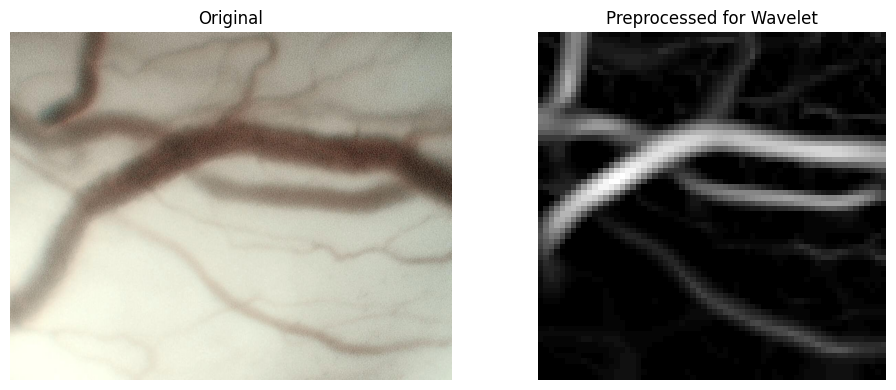

In [33]:
def crop_to_square(img):
    """
    Crops image to square by finding the largest square
    that fits inside the circular endoscopy view.
    Removes the black round borders your teammate mentioned.
    """
    h, w = img.shape[:2]
    # Find the smaller dimension
    min_dim = min(h, w)
    # Calculate crop coordinates to center the square
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    # Crop
    cropped = img[start_h:start_h+min_dim, start_w:start_w+min_dim]
    return cropped


def preprocess_for_wavelet(image_path, img_size=64, use_sato=True):
    """
    Prepares one image for wavelet scattering transform.
    
    Two options:
    - use_sato=True: apply Sato vessel filter first (better for vessel analysis)
    - use_sato=False: just convert to grayscale (simpler, sometimes better)
    """
    # Read image
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    # Crop to square — removes black circular borders
    img = crop_to_square(img)

    # Resize to target size
    img = cv2.resize(img, (img_size, img_size))

    if use_sato:
        # Convert to RGB first
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Extract green channel
        green = img_rgb[:, :, 1]
        # Normalize
        green_norm = green.astype(np.float32) / 255.0
        # Apply Sato filter
        from skimage.filters import sato
        vessel_img = sato(green_norm, sigmas=[1, 2, 3], black_ridges=True)
        # Normalize to 0-255 for scattering
        vessel_img = (vessel_img * 255).astype(np.uint8)
        return vessel_img
    else:
        # Simple grayscale conversion
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return gray


# Test on one image
test_img_path = train_df["image_path"].iloc[0]
result = preprocess_for_wavelet(test_img_path, img_size=64, use_sato=True)

if result is not None:
    print(f"Output shape: {result.shape}")
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    original = cv2.imread(str(test_img_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(result, cmap="gray")
    plt.title("Preprocessed for Wavelet")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [45]:
def extract_wavelet_features(df, img_size=16, use_sato=True):
    """
    Extracts wavelet scattering features from all images.
    Returns feature matrix X and labels y.
    """
    # Initialize Scattering2D
    # J=2 means 2 scales of wavelet decomposition
    # shape = input image dimensions
    scattering = Scattering2D(J=2, shape=(img_size, img_size))
    
    print(f"Extracting features from {len(df)} images...")
    print(f"Image size: {img_size}x{img_size}")
    print(f"Using Sato filter: {use_sato}")
    
    features = []
    labels = []
    patient_ids = []
    valid_indices = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        # Preprocess image
        img = preprocess_for_wavelet(
            row["image_path"],
            img_size=img_size,
            use_sato=use_sato
        )
        
        if img is None:
            continue
        
        # Normalize to 0-1 for scattering
        img_norm = img.astype(np.float32) / 255.0
        
        # Apply wavelet scattering transform
        # Output shape: (channels, height, width)
        scattered = scattering(img_norm)
        
        # Average pooling — collapse spatial dimensions
        # From (217, H, W) to (217,) — one number per scattering coefficient
        feature_vector = scattered.mean(axis=(-2, -1))
        
        features.append(feature_vector)
        labels.append(0 if row["label"] == "Benign" else 1)
        patient_ids.append(row["patient_id"])
        valid_indices.append(idx)
    
    X = np.array(features)
    y = np.array(labels)
    groups = np.array(patient_ids)
    
    print(f"\nFeature matrix shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique patients: {len(np.unique(groups))}")
    
    return X, y, groups


# Extract from training data
X_train, y_train, groups_train = extract_wavelet_features(
    train_df, img_size=16, use_sato=True
)

Extracting features from 6536 images...
Image size: 16x16
Using Sato filter: True


100%|██████████| 6536/6536 [01:38<00:00, 66.24it/s]


Feature matrix shape: (6536, 81)
Labels shape: (6536,)
Unique patients: 115


=== 10-Fold Patient-Level Binary Cross Validation ===

Fold 1: Accuracy = 0.7127 | Binary F1 = 0.6714
Fold 2: Accuracy = 0.5819 | Binary F1 = 0.5473
Fold 3: Accuracy = 0.7275 | Binary F1 = 0.7190
Fold 4: Accuracy = 0.7436 | Binary F1 = 0.7169
Fold 5: Accuracy = 0.5975 | Binary F1 = 0.6170
Fold 6: Accuracy = 0.6340 | Binary F1 = 0.5942
Fold 7: Accuracy = 0.6896 | Binary F1 = 0.6742
Fold 8: Accuracy = 0.6845 | Binary F1 = 0.6241
Fold 9: Accuracy = 0.7650 | Binary F1 = 0.7520
Fold 10: Accuracy = 0.5474 | Binary F1 = 0.5375

Mean Accuracy: 0.6684 ± 0.0703
Mean Binary F1: 0.6453 ± 0.0697

Overall Binary Classification Report:
              precision    recall  f1-score   support

      Benign       0.82      0.59      0.69      4036
   Malignant       0.55      0.79      0.65      2500

    accuracy                           0.67      6536
   macro avg       0.68      0.69      0.67      6536
weighted avg       0.71      0.67      0.67      6536



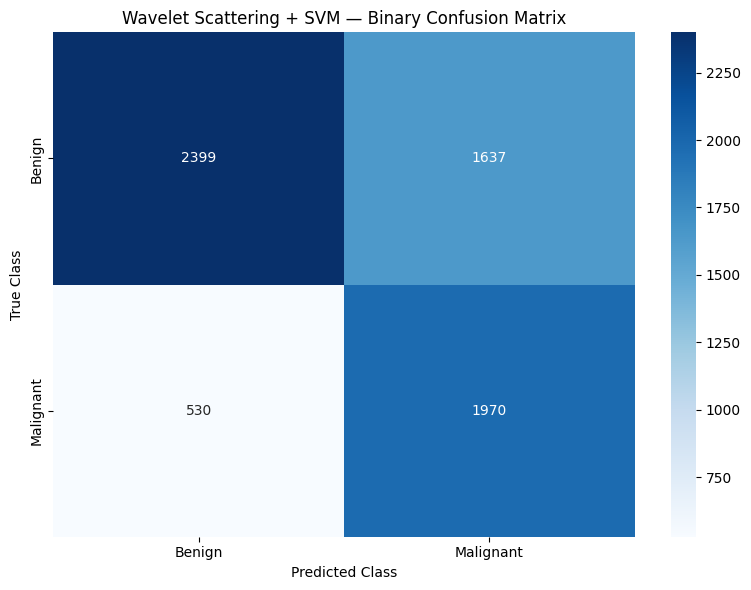

In [46]:


def run_binary_cross_validation(X, y, groups, target_names, n_splits=10):
    """
    10-fold patient-level cross validation for binary targets.
    """
    print(f"=== {n_splits}-Fold Patient-Level Binary Cross Validation ===\n")
    
    # StratifiedGroupKFold balances your binary classes across patient groups perfectly
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=50, random_state=42)),
        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            class_weight='balanced',  # Weights inverse to class frequencies
            random_state=42
        ))
    ])
    
    fold_acc_scores = []
    fold_f1_scores = []
    all_true = []
    all_preds = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=groups)):
        X_fold_train, y_fold_train = X[train_idx], y[train_idx]
        X_fold_val, y_fold_val = X[val_idx], y[val_idx]
        
        # Fit and predict
        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)
        
        # Metrics
        acc = accuracy_score(y_fold_val, preds)
        # CHANGED: Use 'binary' averaging for a standard binary tracking metrics
        f1_bin = f1_score(y_fold_val, preds, average='binary')
        
        fold_acc_scores.append(acc)
        fold_f1_scores.append(f1_bin)
        
        all_true.extend(y_fold_val)
        all_preds.extend(preds)
        
        print(f"Fold {fold+1}: Accuracy = {acc:.4f} | Binary F1 = {f1_bin:.4f}")
    
    print("\n" + "="*50)
    print(f"Mean Accuracy: {np.mean(fold_acc_scores):.4f} ± {np.std(fold_acc_scores):.4f}")
    print(f"Mean Binary F1: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")
    print("="*50)
    
    print("\nOverall Binary Classification Report:")
    print(classification_report(all_true, all_preds, target_names=target_names))

    # Confusion matrix generation
    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Wavelet Scattering + SVM — Binary Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return fold_acc_scores, pipeline

binary_classes = ['Benign', 'Malignant']

fold_scores, cv_pipeline = run_binary_cross_validation(
    X_train,       # Your 0/1 features vector
    y_train,       # Your 0/1 array
    groups_train ,  
    target_names=binary_classes, 
    n_splits=10
)

Extracting test features...
Extracting features from 1861 images...
Image size: 64x64
Using Sato filter: True


100%|██████████| 1861/1861 [00:51<00:00, 35.91it/s]
/user/shrabona.mukherjee/u28600/.conda/envs/biomed_env/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Feature matrix shape: (1861, 81)
Labels shape: (1861,)
Unique patients: 34
=== Training Final Model ===

Test Accuracy: 0.7346

Detailed Report:
              precision    recall  f1-score   support

      Benign       0.83      0.55      0.66       874
   Malignant       0.69      0.90      0.78       987

    accuracy                           0.73      1861
   macro avg       0.76      0.72      0.72      1861
weighted avg       0.76      0.73      0.73      1861



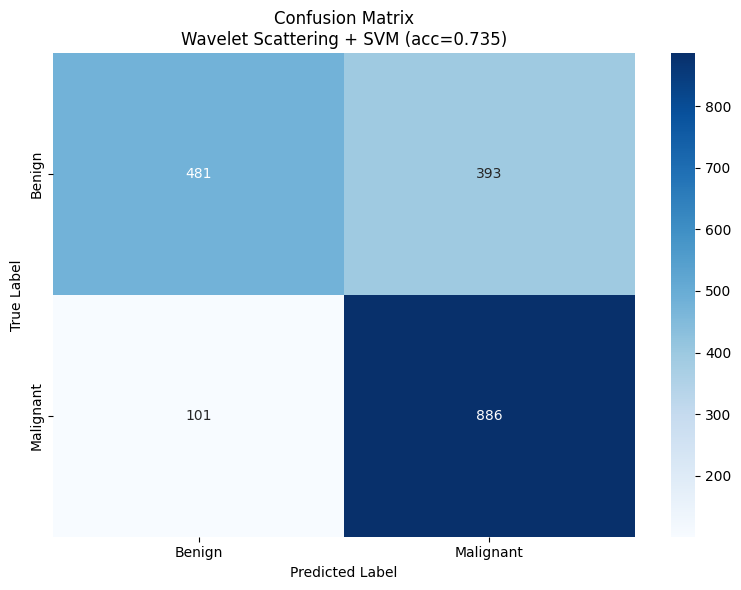

In [ ]:
def train_and_evaluate(X_train, y_train, X_test, y_test, 
                        groups_train, n_pca=50):
    """
    Trains final model on all training data and evaluates on test set.
    """
    print("=== Training Final Model ===")
    
    # Final pipeline
    final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_pca, random_state=42)),
        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            class_weight='balanced',
            random_state=42,
            probability=True  # enables predict_proba for AUC calculation
        ))
    ])
    
    # Fit on ALL training data
    final_pipeline.fit(X_train, y_train)
    
    # Predict on test set
    test_preds = final_pipeline.predict(X_test)
    test_proba = final_pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, test_preds)
    print(f"\nTest Accuracy: {acc:.4f}")
    
    print("\nDetailed Report:")
    print(classification_report(
        y_test, test_preds,
        target_names=["Benign", "Malignant"]
    ))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f'Confusion Matrix\nWavelet Scattering + SVM (acc={acc:.3f})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return final_pipeline, acc


# Extract test features
print("Extracting test features...")
X_test, y_test, groups_test = extract_wavelet_features(
    test_df, img_size=64, use_sato=True
)

# Train and evaluate
final_model, test_acc = train_and_evaluate(
    X_train, y_train, X_test, y_test, groups_train
)

In [47]:
def extract_wavelet_features_multiclass(df, img_size=16, use_sato=True):
    """
    Extracts wavelet scattering features from all images.
    Returns multi-class feature matrix X, integer labels y, and patient groups.
    """
    from kymatio.numpy import Scattering2D
    
    # Initialize Scattering2D
    scattering = Scattering2D(J=2, shape=(img_size, img_size))
    
    print(f"Extracting features from {len(df)} images...")
    print(f"Image size: {img_size}x{img_size}")
    print(f"Using Sato filter: {use_sato}")
    
    # Define multi-class mapping dictionary (0-5)
    conditions_list = [
        'Carcinoma_in_situ', 
        'High_grade_dysplasia', 
        'Low_grade_dysplasia', 
        'Polyp', 
        'Reinkes_edema', 
        'SCC'
    ]
    label_map = {condition: i for i, condition in enumerate(conditions_list)}
    
    features = []
    labels = []
    patient_ids = []
    valid_indices = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        # Preprocess image
        img = preprocess_for_wavelet(
            row["image_path"],
            img_size=img_size,
            use_sato=use_sato
        )
        
        if img is None:
            continue
        
        # Normalize to 0-1 for scattering
        img_norm = img.astype(np.float32) / 255.0
        
        # Apply wavelet scattering transform
        scattered = scattering(img_norm)
        
        # Average pooling — collapse spatial dimensions
        feature_vector = scattered.mean(axis=(-2, -1))
        
        features.append(feature_vector)
        
        # --- THE MULTI-CLASS EDIT IS HERE ---
        # Map the 6 categorical strings directly to an integer token (0 to 5)
        labels.append(label_map[row["condition"]]) 
        
        patient_ids.append(row["patient_id"])
        valid_indices.append(idx)
    
    X = np.array(features)
    y = np.array(labels)
    groups = np.array(patient_ids)
    
    print(f"\nFeature matrix shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Unique target values packed: {np.unique(y)}")
    print(f"Unique patients: {len(np.unique(groups))}")
    
    return X, y, groups

X_train, y_train, groups_train = extract_wavelet_features_multiclass(
    train_df, img_size=16, use_sato=True
)

Extracting features from 6536 images...
Image size: 16x16
Using Sato filter: True


100%|██████████| 6536/6536 [01:38<00:00, 66.31it/s]


Feature matrix shape: (6536, 81)
Labels shape: (6536,)
Unique target values packed: [0 1 2 3 4 5]
Unique patients: 115


=== 10-Fold Patient-Level Multi-Class Cross Validation ===

Fold 1: Accuracy = 0.3393 | Macro F1 = 0.2193
Fold 2: Accuracy = 0.3097 | Macro F1 = 0.2490
Fold 3: Accuracy = 0.3537 | Macro F1 = 0.2431
Fold 4: Accuracy = 0.2905 | Macro F1 = 0.2247
Fold 5: Accuracy = 0.4188 | Macro F1 = 0.3419
Fold 6: Accuracy = 0.2358 | Macro F1 = 0.2157
Fold 7: Accuracy = 0.3706 | Macro F1 = 0.2736
Fold 8: Accuracy = 0.3239 | Macro F1 = 0.2453
Fold 9: Accuracy = 0.4039 | Macro F1 = 0.3660
Fold 10: Accuracy = 0.3694 | Macro F1 = 0.2997

Mean Accuracy: 0.3416 ± 0.0517
Mean Macro F1: 0.2678 ± 0.0496

Overall Multi-Class Classification Report:
                      precision    recall  f1-score   support

   Carcinoma_in_situ       0.08      0.25      0.12       287
High_grade_dysplasia       0.16      0.24      0.19       775
 Low_grade_dysplasia       0.20      0.15      0.17      1157
               Polyp       0.21      0.21      0.21       652
       Reinkes_edema       0.64      0.54      0.59      2227

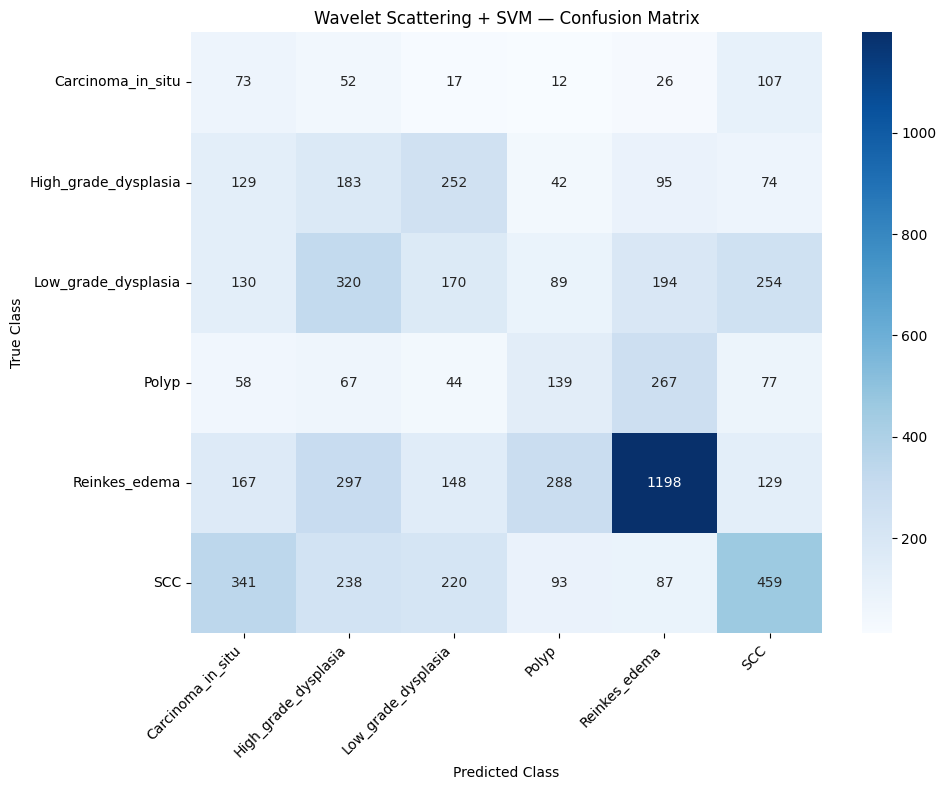

In [50]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix

#  the cross-validation function 
def run_multiclass_cross_validation(X, y, groups, target_names, n_splits=10):
    """
    10-fold patient-level cross validation.
    """
    print(f"=== {n_splits}-Fold Patient-Level Multi-Class Cross Validation ===\n")
    
    # StratifiedGroupKFold balances your 6 classes across patient groups perfectly
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=50, random_state=42)),
        ('svm', SVC(
            kernel='rbf',
            C=10,
            gamma='scale',
            class_weight='balanced',  # Weights inverse to class frequencies
            random_state=42
        ))
    ])
    
    fold_acc_scores = []
    fold_f1_scores = []
    all_true = []
    all_preds = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=groups)):
        X_fold_train, y_fold_train = X[train_idx], y[train_idx]
        X_fold_val, y_fold_val = X[val_idx], y[val_idx]
        
        # Fit and predict
        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)
        
        # Metrics
        acc = accuracy_score(y_fold_val, preds)
        f1_macro = f1_score(y_fold_val, preds, average='macro')
        
        fold_acc_scores.append(acc)
        fold_f1_scores.append(f1_macro)
        
        all_true.extend(y_fold_val)
        all_preds.extend(preds)
        
        print(f"Fold {fold+1}: Accuracy = {acc:.4f} | Macro F1 = {f1_macro:.4f}")
    
    print("\n" + "="*50)
    print(f"Mean Accuracy: {np.mean(fold_acc_scores):.4f} ± {np.std(fold_acc_scores):.4f}")
    print(f"Mean Macro F1: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")
    print("="*50)
    
    print("\nOverall Multi-Class Classification Report:")
    print(classification_report(all_true, all_preds, target_names=target_names))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Wavelet Scattering + SVM — Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return fold_acc_scores, pipeline

conditions_list = [
        'Carcinoma_in_situ', 
        'High_grade_dysplasia', 
        'Low_grade_dysplasia', 
        'Polyp', 
        'Reinkes_edema', 
        'SCC'
    ]

# Execute 
fold_scores, cv_pipeline = run_multiclass_cross_validation(
    X_train, 
    y_train, 
    groups_train, 
    target_names=conditions_list, 
    n_splits=10
)

# 12. Few-Shot Meta-Learning (ProtoNet Pipeline)

This section implements an advanced Deep Learning framework using a custom **Prototypical Neural Network (ProtoNet)** written in PyTorch. 

### What this part does:
1. **Episodic Sampling:** It groups our images into small data subsets called "episodes" using an $N$-way, $K$-shot strategy to train the model on learning from very few examples.
2. **Feature Embedding:** It passes the images through a convolutional neural network to compress them into clean, descriptive feature vectors.
3. **Prototype Clustering:** For each medical condition, it calculates a central mathematical "prototype" or average landmark point using spatial distance formulas (`torch.cdist`).
4. **Classification:** It classifies new images by finding which condition's prototype landmark they are closest to, optimizing the network using negative log-likelihood loss.

---

### How we apply it across classification tasks:

* **Binary Task (Benign vs. Malignant):** The model is evaluated on a 2-way episodic structure to learn the broad, high-level features that separate non-cancerous frames from cancerous ones.
* **Multiclass Task (6 Pathological Conditions):** The model expands to a multi-way task, setting up separate prototypes for all 6 granular tissue conditions simultaneously to separate visually similar diseases.
* **Hierarchical Pipeline Task:** The ProtoNet logic can be deployed at individual decision checkpoints within a cascading tree—first routing a sample at the root gate (Binary), and then passing it down to specialized sub-networks focused exclusively on identifying the precise tissue condition.

In [2]:
base_dir = Path("CE-NBI_Dataset_Unpacked/CE-NBI_Dataset")

folders = ["Testing", "Training"]
paths = [p for folder in folders for p in Path(base_dir/folder).rglob("*.jpg")]

paths_df = (
    pd.DataFrame({
        "path": paths,
        "split": [p.parts[2] for p in paths], # test/train
        "patient": [p.parts[5] for p in paths],
        "filename": [p.parts[6] for p in paths],
        "label": [p.parts[3] for p in paths], # benign/malignant
        "type": [p.parts[4] for p in paths], # the 6 lesion types
    })
)

paths_df.sample(10)

,path,split,patient,filename,label,type
5852,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient184,P184 (48).jpg,Benign,Reinkes_edema
2597,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient129,P129 (31).jpg,Benign,Low_grade_dysplasia
677,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Testing...,Testing,Patient197,P197 (18).jpg,Benign,Reinkes_edema
4716,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient089,P089 (12).jpg,Benign,Reinkes_edema
3233,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient096,P096 (15).jpg,Benign,Polyp
3943,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient043,P043 (34).jpg,Benign,Reinkes_edema
5023,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient134,P134 (10).jpg,Benign,Reinkes_edema
8153,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient126,P126 (22).jpg,Malignant,SCC
6712,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient153,P153 (1).jpg,Malignant,High_grade_dysplasia
7296,CE-NBI_Dataset_Unpacked/CE-NBI_Dataset/Trainin...,Training,Patient097,P097 (18).jpg,Malignant,SCC


Train: 5432 images
Val: 1104 images
Train class distribution:
condition
Reinkes_edema           1972
SCC                     1252
Low_grade_dysplasia      739
High_grade_dysplasia     665
Polyp                    539
Carcinoma_in_situ        265
Name: count, dtype: int64
Using device: cuda
Training for 500 episodes...
Episode 5: train_acc=0.217, val_acc=0.314
  → Saved best model weights!
Episode 10: train_acc=0.353, val_acc=0.353
  → Saved best model weights!
Episode 15: train_acc=0.423, val_acc=0.350
Episode 20: train_acc=0.463, val_acc=0.365
  → Saved best model weights!
Episode 25: train_acc=0.513, val_acc=0.344
Episode 30: train_acc=0.533, val_acc=0.342
Episode 35: train_acc=0.517, val_acc=0.327
Episode 40: train_acc=0.443, val_acc=0.307
Episode 45: train_acc=0.533, val_acc=0.344
🛑 Early stopping triggered at episode 45!

Best validation accuracy: 0.3650

Final Multi-Channel Patient-Level ProtoNet Report:
                      precision    recall  f1-score   support

   Carcinoma_

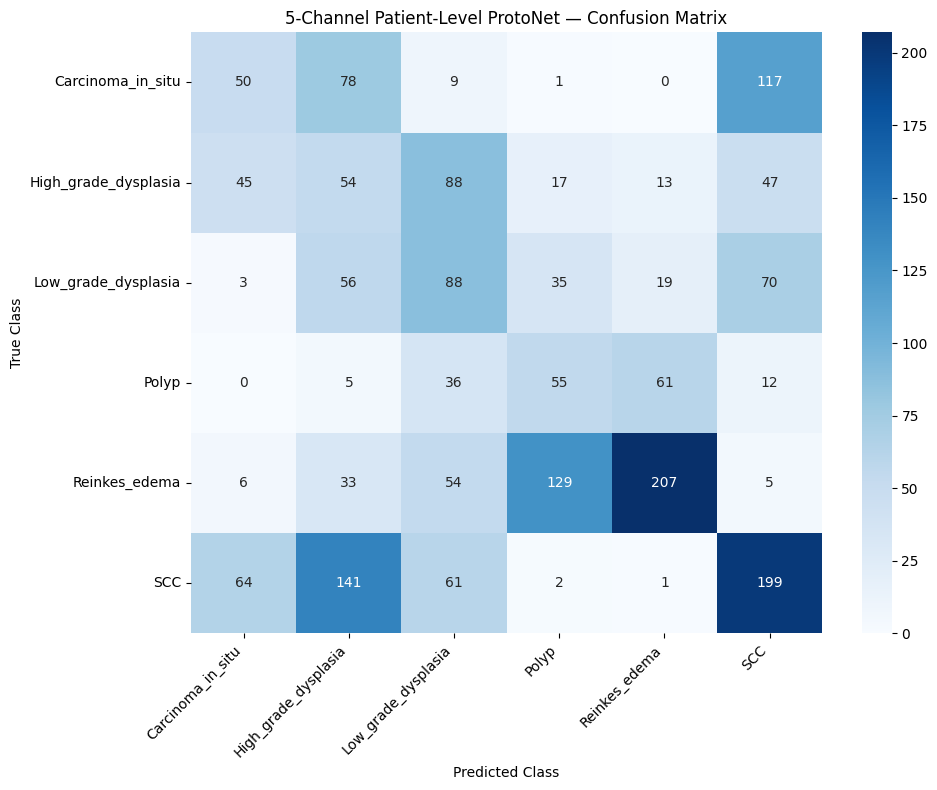

In [37]:
import ssl
# Global override to allow model downloads through strict institutional proxies
ssl._create_default_https_context = ssl._create_unverified_context



warnings.filterwarnings("ignore", category=FutureWarning)

# ── 0. Hybrid 5-Channel Processing Feature Engine ──
def path_to_combined(image_path, img_size=128):
    """
    Combines RGB (3 channels) + Sato filter response (1 channel) + Binary Skeleton (1 channel)
    Returns a unified 5-channel tensor of shape [5, img_size, img_size]
    Optimized to 128x128 resolution to ensure stability within GPU memory constraints.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return torch.zeros(5, img_size, img_size, dtype=torch.float32)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    
    # Extract structural layers
    green = img_resized[:, :, 1]
    inverted = 255 - green
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    tophat = cv2.morphologyEx(inverted, cv2.MORPH_TOPHAT, kernel)
    normalized = tophat.astype(np.float32) / 255.0
    
    sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)
    threshold = np.percentile(sato_r, 80)
    binary_mask = sato_r > threshold
    skeleton_bool = skeletonize(binary_mask)
    clean_skeleton = remove_small_objects(skeleton_bool, min_size=3)
    
    # Cast and normalize channels down to standard scaling boundaries
    skeleton_img = clean_skeleton.astype(np.float32)
    sato_img = sato_r.astype(np.float32)
    rgb_norm = img_resized.astype(np.float32) / 255.0
    
    # Stack into an integrated structural feature tensor [5, H, W]
    combined = np.concatenate([
        rgb_norm.transpose(2, 0, 1),       # Channels 0, 1, 2 (RGB)
        sato_img[np.newaxis, :, :],        # Channel 3 (Vessels)
        skeleton_img[np.newaxis, :, :]     # Channel 4 (Skeletons)
    ], axis=0)
    
    return torch.tensor(combined, dtype=torch.float32)

# ── 1. Dataset ──
class CEMBIDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        # Map condition to number
        self.conditions = sorted(df["condition"].unique())
        self.label_map = {c: i for i, c in enumerate(self.conditions)}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Modifications handle operations inside the episodic generator instead
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.label_map[row["condition"]]
        return img, label, row["patient_id"]

# ── 2. Backbone — Modified EfficientNet for 5-Channel Processing ──
class ProtoNet(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        # Load pretrained EfficientNetV2
        backbone = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )
        
        # Pull native first layer settings
        old_conv = backbone.features[0][0]
        
        # Expand target input channel parameter architecture to 5 channels
        new_conv = nn.Conv2d(
            in_channels=5,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        
        # Bind pre-trained ImageNet parameters to the primary RGB arrays
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            nn.init.kaiming_normal_(new_conv.weight[:, 3:, :, :], mode='fan_out', nonlinearity='relu')
            
        backbone.features[0][0] = new_conv
        
        # Remove classification head — keep only feature extractor
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        # Project to embedding dimension
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projector(features)
        # Unit re-normalization step to protect spatial clusters
        return F.normalize(embeddings, p=2, dim=1)

# ── 3. Prototypical Loss — Patient Level Averaging ──
def prototypical_loss(support_embeddings, support_labels, support_patients,
                      query_embeddings, query_labels, n_classes):
    
    device = support_embeddings.device
    prototypes = []
    
    # --- CRITICAL FIX: Ensure mask can index this by matching array types ---
    # Convert mask to CPU numpy if indexing numpy, or keep it clean
    for c in range(n_classes):
        mask = (support_labels == c)
        if mask.sum() == 0:
            prototypes.append(torch.zeros(support_embeddings.shape[1], device=device))
        else:
            c_embeddings = support_embeddings[mask]
            
            # Move the mask to CPU to safely index the numpy array of patient IDs
            cpu_mask = mask.cpu().numpy()
            c_patients = support_patients[cpu_mask]
            
            # Group embeddings by patient id first
            unique_patients = np.unique(c_patients)
            patient_means = []
            for p_id in unique_patients:
                p_mask = c_patients == p_id
                patient_means.append(c_embeddings[p_mask].mean(0))
                
            # Take the mean of patient averages to form final class center
            class_proto = torch.stack(patient_means).mean(0)
            class_proto = F.normalize(class_proto, p=2, dim=0)
            prototypes.append(class_proto)
    
    prototypes = torch.stack(prototypes)
    dists = torch.cdist(query_embeddings, prototypes)
    log_probs = F.log_softmax(-dists, dim=1)
    
    loss = F.nll_loss(log_probs, query_labels)
    preds = log_probs.argmax(dim=1)
    acc = (preds == query_labels).float().mean()
    
    return loss, acc, preds

# ── 4. Episode Sampler ──
def sample_episode(df, n_way=6, n_support=5, n_query=10, label_map=None):
    """
    Samples one training episode tracking patient identifiers alongside label tracks
    """
    conditions = df["condition"].unique()
    
    # Sample n_way classes (all 6 for our case)
    selected_classes = np.random.choice(
        conditions, 
        min(n_way, len(conditions)), 
        replace=False
    )
    
    support_imgs, support_labels, support_patients = [], [], []
    query_imgs, query_labels = [], []
    
    for i, condition in enumerate(selected_classes):
        class_df = df[df["condition"] == condition]
        
        # Need at least n_support + n_query images
        if len(class_df) < n_support + n_query:
            n_s = max(1, len(class_df) // 2)
            n_q = len(class_df) - n_s
        else:
            n_s, n_q = n_support, n_query
        
        # Sample without replacement
        sampled = class_df.sample(n_s + n_q, replace=False if len(class_df) >= (n_s + n_q) else True)
        support_rows = sampled.iloc[:n_s]
        query_rows = sampled.iloc[n_s:]
        
        for _, row in support_rows.iterrows():
            support_imgs.append(row["image_path"])
            support_labels.append(i)
            support_patients.append(row["patient_id"]) # Track matching patient strings
        
        for _, row in query_rows.iterrows():
            query_imgs.append(row["image_path"])
            query_labels.append(i)
    
    return (support_imgs, support_labels, support_patients,
            query_imgs, query_labels, selected_classes)

# ── 5. Matched Training Loop ──
def train_protonet(train_df, val_df, n_episodes=500, 
                   n_way=6, n_support=5, n_query=10,
                   embedding_dim=512, lr=1e-4, patience=5):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Use standard validation RGB normalization transforms over channel index slice
    transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    model = ProtoNet(embedding_dim=embedding_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
    
    # Generate the map for this training run
    conditions = sorted(train_df["condition"].unique())
    label_map = {c: i for i, c in enumerate(conditions)}
    
    train_accs = []
    best_val_acc = 0.0
    patience_counter = 0 
    
    print(f"Training for {n_episodes} episodes...")
    
    for episode in range(n_episodes):
        model.train()
        
        (sup_imgs, sup_labels, sup_patients, qry_imgs, qry_labels, selected_classes) = sample_episode(
            train_df, n_way=n_way, n_support=n_support, n_query=n_query
        )
        
        def load_imgs(paths):
            imgs = []
            for p in paths:
                try:
                    # Dynamically compute the 5-channel hybrid structure at 128x128
                    t_5ch = path_to_combined(p, img_size=128)
                    # Normalize explicitly across the standard RGB layers (0, 1, 2)
                    t_5ch[:3, :, :] = transform_norm(t_5ch[:3, :, :])
                    imgs.append(t_5ch)
                except:
                    imgs.append(torch.zeros(5, 128, 128))
            return torch.stack(imgs).to(device)
        
        sup_tensors = load_imgs(sup_imgs)
        qry_tensors = load_imgs(qry_imgs)
        sup_label_tensor = torch.tensor(sup_labels).to(device)
        qry_label_tensor = torch.tensor(qry_labels).to(device)
        sup_patients_arr = np.array(sup_patients)
        
        sup_embeddings = model(sup_tensors)
        qry_embeddings = model(qry_tensors)
        
        loss, acc, _ = prototypical_loss(
            sup_embeddings, sup_label_tensor, sup_patients_arr,
            qry_embeddings, qry_label_tensor,
            n_classes=len(selected_classes)
        )
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        train_accs.append(acc.item())
        
        # Validate every 5 episodes
        if (episode + 1) % 5 == 0:
            val_acc = evaluate_protonet(
                model=model,
                support_df=train_df,
                query_df=val_df,
                label_map=label_map,
                device=device,
                n_support=n_support
            )
            mean_train = np.mean(train_accs[-5:])
            print(f"Episode {episode+1}: train_acc={mean_train:.3f}, val_acc={val_acc:.3f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), "best_protonet.pt")
                print(f"  → Saved best model weights!")
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"🛑 Early stopping triggered at episode {episode+1}!")
                break
                
    return model, best_val_acc

# ── 6. Matched Evaluation Routine with Patient Prototypes ──
def evaluate_protonet(model, support_df, query_df, label_map, device, n_support=10):
    model.eval()
    
    transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    def load_img(path):
        try:
            t_5ch = path_to_combined(path, img_size=128)
            t_5ch[:3, :, :] = transform_norm(t_5ch[:3, :, :])
            return t_5ch
        except:
            return torch.zeros(5, 128, 128)
            
    conditions = sorted(support_df["condition"].unique())
    img_col = "path" if "path" in support_df.columns else "image_path"
    
    with torch.no_grad():
        prototypes = []
        for condition in conditions:
            class_df = support_df[support_df["condition"] == condition]
            
            # Option B Fix: Average representations per patient first
            patient_means = []
            unique_patients = class_df["patient_id"].unique()
            
            for p_id in unique_patients:
                p_df = class_df[class_df["patient_id"] == p_id]
                if len(p_df) > n_support:
                    p_df = p_df.sample(n_support, random_state=42)
                    
                paths_list = p_df[img_col].tolist()
                imgs = torch.stack([load_img(p) for p in paths_list]).to(device)
                embeddings = model(imgs)
                patient_means.append(embeddings.mean(0))
                
            if len(patient_means) == 0:
                prototypes.append(torch.zeros(512, device=device))
            else:
                class_proto = torch.stack(patient_means).mean(0)
                # Hypersphere re-normalization
                class_proto = F.normalize(class_proto, p=2, dim=0)
                prototypes.append(class_proto)
        
        prototypes = torch.stack(prototypes)
        all_preds, all_true = [], []
        
        query_paths = query_df[img_col].tolist()
        query_types = query_df["condition"].tolist()
        
        for p, t in zip(query_paths, query_types):
            img = load_img(p).unsqueeze(0).to(device)
            embedding = model(img)
            
            dists = torch.cdist(embedding, prototypes.unsqueeze(0))[0]
            pred = dists.argmin().item()
            
            true = label_map[t]
            
            all_preds.append(pred)
            all_true.append(true)
            
        acc = accuracy_score(all_true, all_preds)
    return acc

# ── 7. Run Everything ──
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
split = gss.split(train_df, groups=train_df["patient_id"])
train_idx, val_idx = next(split)

proto_train_df = train_df.iloc[train_idx].reset_index(drop=True)
proto_val_df = train_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(proto_train_df)} images")
print(f"Val: {len(proto_val_df)} images")
print(f"Train class distribution:")
print(proto_train_df["condition"].value_counts())

# Train execution
model, best_val_acc = train_protonet(
    proto_train_df, proto_val_df,
    n_episodes=500,    
    n_way=6,
    n_support=5,       
    n_query=10,        
    embedding_dim=512,
    lr=1e-4
)

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# ==========================================================
# FINAL COMPREHENSIVE DEPLOYMENT REPORT & METRICS GENERATION
# ==========================================================
conditions = sorted(train_df["condition"].unique())
label_map = {c: i for i, c in enumerate(conditions)}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best functional structural weights
model.load_state_dict(torch.load("best_protonet.pt", map_location=device))
model.eval()

img_col = "path" if "path" in test_df.columns else "image_path"
all_true_test = [label_map[t] for t in test_df["condition"].tolist()]
all_preds_test = []

transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Statically calculate validation testing prototypes at 128x128 boundaries
with torch.no_grad():
    prototypes = []
    for condition in conditions:
        class_df = proto_train_df[proto_train_df["condition"] == condition]
        patient_means = []
        for p_id in class_df["patient_id"].unique():
            p_df = class_df[class_df["patient_id"] == p_id].sample(min(20, len(class_df)), random_state=42, replace=True)
            imgs = torch.stack([path_to_combined(p, 128) for p in p_df[img_col]]).to(device)
            imgs[:, :3, :, :] = torch.stack([transform_norm(im[:3, :, :]) for im in imgs])
            patient_means.append(model(imgs).mean(0))
        class_proto = torch.stack(patient_means).mean(0)
        prototypes.append(F.normalize(class_proto, p=2, dim=0))
    prototypes = torch.stack(prototypes)

    # Classify out-of-fold testing sets
    for p in test_df[img_col].tolist():
        img = path_to_combined(p, 128).unsqueeze(0).to(device)
        img[:, :3, :, :] = transform_norm(img[:, :3, :, :])
        emb = model(img)
        all_preds_test.append(torch.cdist(emb, prototypes).argmin().item())

# Display final metric breakdown summaries
print("\nFinal Multi-Channel Patient-Level ProtoNet Report:")
print(classification_report(all_true_test, all_preds_test, target_names=conditions))

cm = confusion_matrix(all_true_test, all_preds_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=conditions, yticklabels=conditions)
plt.title('5-Channel Patient-Level ProtoNet — Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Using device: cuda
Training Binary 5-Channel ProtoNet for 500 episodes...
Episode 5: train_acc=0.690, val_acc=0.700
  → Saved best model weights!
Episode 10: train_acc=0.810, val_acc=0.677
Episode 15: train_acc=0.690, val_acc=0.659
Episode 20: train_acc=0.760, val_acc=0.660
Episode 25: train_acc=0.870, val_acc=0.661
Episode 30: train_acc=0.790, val_acc=0.684
🛑 Early stopping triggered at episode 30!

Best Validation Accuracy: 0.7002
              precision    recall  f1-score   support

      Benign       0.83      0.65      0.73       874
   Malignant       0.74      0.89      0.81       987

    accuracy                           0.77      1861
   macro avg       0.79      0.77      0.77      1861
weighted avg       0.78      0.77      0.77      1861



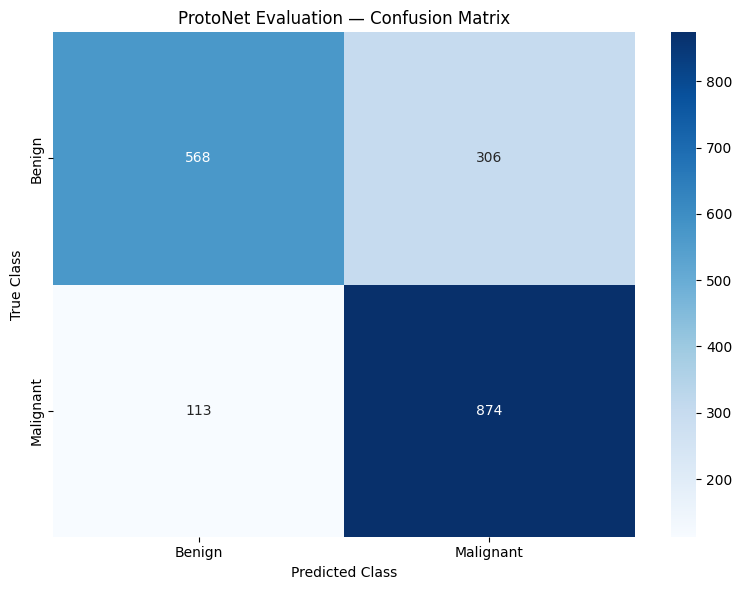

In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── 0. Split & Binary Setup ──
binary_conditions = ['Benign', 'Malignant']

binary_map = {
    'Polyp': 0,                 
    'Reinkes_edema': 0,         
    'Low_grade_dysplasia': 0,    
    'High_grade_dysplasia': 1,   
    'Carcinoma_in_situ': 1,     
    'SCC': 1                    
}

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
split = gss.split(train_df, groups=train_df["patient_id"])
train_idx, val_idx = next(split)

proto_train_df = train_df.iloc[train_idx].reset_index(drop=True)
proto_val_df = train_df.iloc[val_idx].reset_index(drop=True)

proto_train_df['condition'] = proto_train_df['condition'].map(binary_map).copy()
proto_val_df['condition'] = proto_val_df['condition'].map(binary_map).copy()

# ── 1. Hybrid 5-Channel Processing Feature Engine ──
def path_to_combined(image_path, img_size=128):
    img = cv2.imread(str(image_path))
    if img is None:
        return torch.zeros(5, img_size, img_size, dtype=torch.float32)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    
    green = img_resized[:, :, 1]
    inverted = 255 - green
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    tophat = cv2.morphologyEx(inverted, cv2.MORPH_TOPHAT, kernel)
    normalized = tophat.astype(np.float32) / 255.0
    
    sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)
    threshold = np.percentile(sato_r, 80)
    binary_mask = sato_r > threshold
    skeleton_bool = skeletonize(binary_mask)
    clean_skeleton = remove_small_objects(skeleton_bool, min_size=3)
    
    skeleton_img = clean_skeleton.astype(np.float32)
    sato_img = sato_r.astype(np.float32)
    rgb_norm = img_resized.astype(np.float32) / 255.0
    
    combined = np.concatenate([
        rgb_norm.transpose(2, 0, 1),       
        sato_img[np.newaxis, :, :],        
        skeleton_img[np.newaxis, :, :]     
    ], axis=0)
    
    return torch.tensor(combined, dtype=torch.float32)

# ── 2. Backbone — Modified EfficientNet for 5-Channel Processing ──
class ProtoNet(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        backbone = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )
        
        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels=5,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            nn.init.kaiming_normal_(new_conv.weight[:, 3:, :, :], mode='fan_out', nonlinearity='relu')
            
        backbone.features[0][0] = new_conv
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projector(features)
        return F.normalize(embeddings, p=2, dim=1)

# ── 3. Prototypical Loss — Patient Level Averaging ──
def prototypical_loss(support_embeddings, support_labels, support_patients,
                      query_embeddings, query_labels, n_classes):
    device = support_embeddings.device
    prototypes = []
    
    for c in range(n_classes):
        mask = (support_labels == c)
        if mask.sum() == 0:
            prototypes.append(torch.zeros(support_embeddings.shape[1], device=device))
        else:
            c_embeddings = support_embeddings[mask]
            cpu_mask = mask.cpu().numpy()
            c_patients = support_patients[cpu_mask]
            
            unique_patients = np.unique(c_patients)
            patient_means = []
            for p_id in unique_patients:
                p_mask = (c_patients == p_id)
                patient_means.append(c_embeddings[p_mask].mean(0))
                
            class_proto = torch.stack(patient_means).mean(0)
            class_proto = F.normalize(class_proto, p=2, dim=0)
            prototypes.append(class_proto)
    
    prototypes = torch.stack(prototypes)
    dists = torch.cdist(query_embeddings, prototypes)
    log_probs = F.log_softmax(-dists, dim=1)
    
    loss = F.nll_loss(log_probs, query_labels)
    preds = log_probs.argmax(dim=1)
    acc = (preds == query_labels).float().mean()
    
    return loss, acc, preds

# ── 4. Episode Sampler ──
def sample_episode(df, n_way=2, n_support=5, n_query=10, label_map=None):
    conditions = [0, 1]
    selected_classes = np.array(conditions)
    
    support_imgs, support_labels, support_patients = [], [], []
    query_imgs, query_labels = [], []
    
    for i, condition in enumerate(selected_classes):
        class_df = df[df["condition"] == condition]
        
        if len(class_df) < n_support + n_query:
            n_s = max(1, len(class_df) // 2)
            n_q = len(class_df) - n_s
        else:
            n_s, n_q = n_support, n_query
        
        sampled = class_df.sample(n_s + n_q, replace=False if len(class_df) >= (n_s + n_q) else True)
        support_rows = sampled.iloc[:n_s]
        query_rows = sampled.iloc[n_s:]
        
        for _, row in support_rows.iterrows():
            support_imgs.append(row["image_path"])
            support_labels.append(i)
            support_patients.append(row["patient_id"]) 
        
        for _, row in query_rows.iterrows():
            query_imgs.append(row["image_path"])
            query_labels.append(i)
    
    return (support_imgs, support_labels, support_patients,
            query_imgs, query_labels, selected_classes)

# ── 5. Training Loop ──
def train_protonet(train_df, val_df, n_episodes=500, 
                   n_way=2, n_support=5, n_query=10,
                   embedding_dim=512, lr=1e-4, patience=5):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    model = ProtoNet(embedding_dim=embedding_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)
    
    train_accs = []
    best_val_acc = 0.0
    patience_counter = 0 
    
    def load_imgs(paths):
        imgs = []
        for p in paths:
            try:
                t_5ch = path_to_combined(p, img_size=128)
                t_5ch[:3, :, :] = transform_norm(t_5ch[:3, :, :])
                imgs.append(t_5ch)
            except:
                imgs.append(torch.zeros(5, 128, 128))
        return torch.stack(imgs).to(device)
    
    print(f"Training Binary 5-Channel ProtoNet for {n_episodes} episodes...")
    
    for episode in range(n_episodes):
        model.train()
        
        (sup_imgs, sup_labels, sup_patients, qry_imgs, qry_labels, selected_classes) = sample_episode(
            train_df, n_way=n_way, n_support=n_support, n_query=n_query
        )
        
        sup_tensors = load_imgs(sup_imgs)
        qry_tensors = load_imgs(qry_imgs)
        sup_label_tensor = torch.tensor(sup_labels).to(device)
        qry_label_tensor = torch.tensor(qry_labels).to(device)
        sup_patients_arr = np.array(sup_patients)
        
        sup_embeddings = model(sup_tensors)
        qry_embeddings = model(qry_tensors)
        
        loss, acc, _ = prototypical_loss(
            sup_embeddings, sup_label_tensor, sup_patients_arr,
            qry_embeddings, qry_label_tensor,
            n_classes=len(selected_classes)
        )
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        train_accs.append(acc.item())
        
        if (episode + 1) % 5 == 0:
            val_acc = evaluate_protonet(
                model=model, support_df=train_df, query_df=val_df, device=device, n_support=n_support
            )
            mean_train = np.mean(train_accs[-5:])
            print(f"Episode {episode+1}: train_acc={mean_train:.3f}, val_acc={val_acc:.3f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), "best_binary_protonet.pt")
                print(f"  → Saved best model weights!")
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f"🛑 Early stopping triggered at episode {episode+1}!")
                break
                
    return model, best_val_acc

# ── 6. Evaluation Routine ──
def evaluate_protonet(model, support_df, query_df, device, n_support=10):
    model.eval()
    transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    def load_img(path):
        try:
            t_5ch = path_to_combined(path, img_size=128)
            t_5ch[:3, :, :] = transform_norm(t_5ch[:3, :, :])
            return t_5ch
        except:
            return torch.zeros(5, 128, 128)
            
    conditions = [0, 1]
    img_col = "path" if "path" in support_df.columns else "image_path"
    
    with torch.no_grad():
        prototypes = []
        for condition in conditions:
            class_df = support_df[support_df["condition"] == condition]
            patient_means = []
            unique_patients = class_df["patient_id"].unique()
            
            for p_id in unique_patients:
                p_df = class_df[class_df["patient_id"] == p_id]
                if len(p_df) > n_support:
                    p_df = p_df.sample(n_support, random_state=42)
                    
                paths_list = p_df[img_col].tolist()
                imgs = torch.stack([load_img(p) for p in paths_list]).to(device)
                embeddings = model(imgs)
                patient_means.append(embeddings.mean(0))
                
            if len(patient_means) == 0:
                prototypes.append(torch.zeros(512, device=device))
            else:
                class_proto = torch.stack(patient_means).mean(0)
                class_proto = F.normalize(class_proto, p=2, dim=0)
                prototypes.append(class_proto)
        
        prototypes = torch.stack(prototypes)
        all_preds, all_true = [], []
        
        query_paths = query_df[img_col].tolist()
        query_types = query_df["condition"].tolist()
        
        for p, t in zip(query_paths, query_types):
            img = load_img(p).unsqueeze(0).to(device)
            embedding = model(img)
            
            dists = torch.cdist(embedding, prototypes.unsqueeze(0))[0]
            pred = dists.argmin().item()
            
            all_preds.append(pred)
            all_true.append(t)
            
        acc = accuracy_score(all_true, all_preds)
    return acc

# ── 7. Run Train Pipeline ──
model, best_val_acc = train_protonet(
    proto_train_df, proto_val_df,
    n_episodes=500,    
    n_way=2,
    n_support=5,       
    n_query=10,        
    embedding_dim=512,
    lr=1e-4
)

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

# ── 8. Generate Final Test Performance Analytics ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_binary_protonet.pt", map_location=device))
model.eval()

img_col = "path" if "path" in test_df.columns else "image_path"

all_true_test = test_df["condition"].map(binary_map).tolist()
all_preds_test = []

transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

with torch.no_grad():
    prototypes = []
    for c_idx in [0, 1]:
        class_df = proto_train_df[proto_train_df["condition"] == c_idx]
        patient_means = []
        for p_id in class_df["patient_id"].unique():
            p_df = class_df[class_df["patient_id"] == p_id].sample(min(20, len(class_df)), random_state=42, replace=True)
            imgs = torch.stack([path_to_combined(p, 128) for p in p_df[img_col]]).to(device)
            imgs[:, :3, :, :] = torch.stack([transform_norm(im[:3, :, :]) for im in imgs])
            patient_means.append(model(imgs).mean(0))
        class_proto = torch.stack(patient_means).mean(0)
        prototypes.append(F.normalize(class_proto, p=2, dim=0))
    prototypes = torch.stack(prototypes)

    for p in test_df[img_col].tolist():
        img = path_to_combined(p, 128).unsqueeze(0).to(device)
        img[:, :3, :, :] = transform_norm(img[:, :3, :, :])
        emb = model(img)
        all_preds_test.append(torch.cdist(emb, prototypes).argmin().item())

print(classification_report(all_true_test, all_preds_test, target_names=binary_conditions))

cm = confusion_matrix(all_true_test, all_preds_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=binary_conditions, yticklabels=binary_conditions)
plt.title('ProtoNet Evaluation — Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

Training Hierarchical Component: Node [stage1]...
Training Hierarchical Component: Node [benign]...
Training Hierarchical Component: Node [malignant]...

STAGE 1: BINARY ROOT NODE (Benign vs Malignant)
              precision    recall  f1-score   support

      Benign       0.84      0.76      0.80       874
   Malignant       0.80      0.87      0.84       987

    accuracy                           0.82      1861
   macro avg       0.82      0.81      0.82      1861
weighted avg       0.82      0.82      0.82      1861


STAGE 2: BENIGN LEAF NODE (Polyp vs Reinke's vs Low-Grade)
                     precision    recall  f1-score   support

              Polyp       0.02      0.01      0.01       169
      Reinkes_edema       0.64      0.79      0.71       434
Low_grade_dysplasia       0.80      0.83      0.82       271

           accuracy                           0.65       874
          macro avg       0.49      0.54      0.51       874
       weighted avg       0.57      0.65   

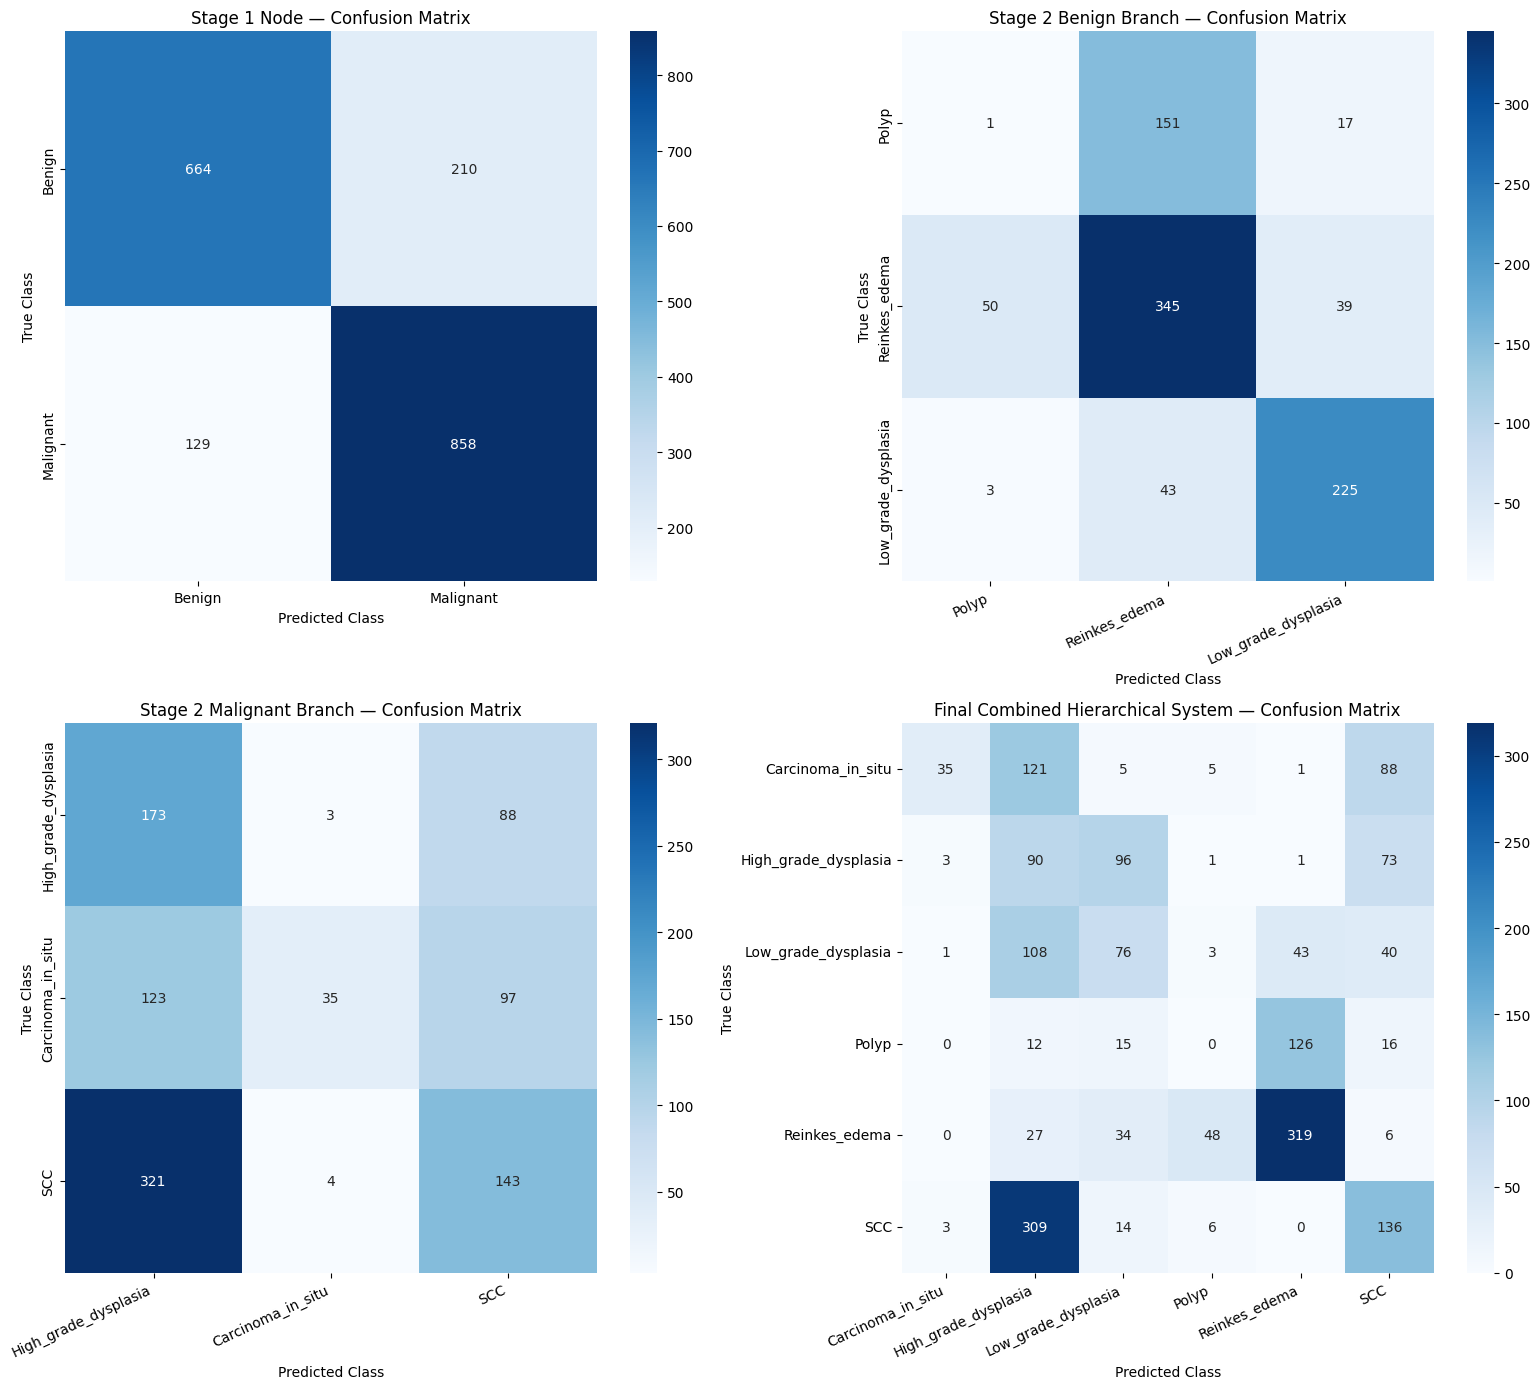

In [54]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


# Hierarchical Data Mapping Definitions 
conditions_list = ['Carcinoma_in_situ', 'High_grade_dysplasia', 'Low_grade_dysplasia', 'Polyp', 'Reinkes_edema', 'SCC']
label_map_6class = {c: i for i, c in enumerate(conditions_list)}

benign_classes = ['Polyp', 'Reinkes_edema', 'Low_grade_dysplasia']
malignant_classes = ['High_grade_dysplasia', 'Carcinoma_in_situ', 'SCC']

# Create mapping dictionary from 6-class index to its sub-model level index
sub_label_maps = {
    'benign': {c: i for i, c in enumerate(benign_classes)},
    'malignant': {c: i for i, c in enumerate(malignant_classes)}
}

# Split base dataset at patient level
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
split = gss.split(train_df, groups=train_df["patient_id"])
train_idx, val_idx = next(split)

proto_train_df = train_df.iloc[train_idx].reset_index(drop=True)
proto_val_df = train_df.iloc[val_idx].reset_index(drop=True)

# ── 1. Feature Engineering Engine ──
def path_to_combined(image_path, img_size=128):
    img = cv2.imread(str(image_path))
    if img is None:
        return torch.zeros(5, img_size, img_size, dtype=torch.float32)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    
    green = img_resized[:, :, 1]
    inverted = 255 - green
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    tophat = cv2.morphologyEx(inverted, cv2.MORPH_TOPHAT, kernel)
    normalized = tophat.astype(np.float32) / 255.0
    
    sato_r = sato(normalized, sigmas=[1, 2, 3], black_ridges=True)
    threshold = np.percentile(sato_r, 80)
    binary_mask = sato_r > threshold
    skeleton_bool = skeletonize(binary_mask)
    clean_skeleton = remove_small_objects(skeleton_bool, min_size=3)
    
    skeleton_img = clean_skeleton.astype(np.float32)
    sato_img = sato_r.astype(np.float32)
    rgb_norm = img_resized.astype(np.float32) / 255.0
    
    combined = np.concatenate([
        rgb_norm.transpose(2, 0, 1),
        sato_img[np.newaxis, :, :],
        skeleton_img[np.newaxis, :, :]
    ], axis=0)
    
    return torch.tensor(combined, dtype=torch.float32)

# ── 2. Network Backbone ──
class ProtoNet(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        old_conv = backbone.features[0][0]
        
        new_conv = nn.Conv2d(
            in_channels=5, out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )
        
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            nn.init.kaiming_normal_(new_conv.weight[:, 3:, :, :], mode='fan_out', nonlinearity='relu')
            
        backbone.features[0][0] = new_conv
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
    
    def forward(self, x):
        features = self.encoder(x)
        embeddings = self.projector(features)
        return F.normalize(embeddings, p=2, dim=1)

# ── 3. Prototypical Distance Loss ──
def prototypical_loss(support_embeddings, support_labels, support_patients,
                      query_embeddings, query_labels, n_classes):
    device = support_embeddings.device
    prototypes = []
    
    for c in range(n_classes):
        mask = (support_labels == c)
        if mask.sum() == 0:
            prototypes.append(torch.zeros(support_embeddings.shape[1], device=device))
        else:
            c_embeddings = support_embeddings[mask]
            cpu_mask = mask.cpu().numpy()
            c_patients = support_patients[cpu_mask]
            
            unique_patients = np.unique(c_patients)
            patient_means = []
            for p_id in unique_patients:
                p_mask = (c_patients == p_id)
                patient_means.append(c_embeddings[p_mask].mean(0))
                
            class_proto = torch.stack(patient_means).mean(0)
            class_proto = F.normalize(class_proto, p=2, dim=0)
            prototypes.append(class_proto)
            
    prototypes = torch.stack(prototypes)
    dists = torch.cdist(query_embeddings, prototypes)
    log_probs = F.log_softmax(-dists, dim=1)
    
    loss = F.nll_loss(log_probs, query_labels)
    preds = log_probs.argmax(dim=1)
    acc = (preds == query_labels).float().mean()
    
    return loss, acc, preds

# ── 4. Hierarchical Episodic Sampler ──
def sample_hierarchical_episode(df, target_mode, n_classes, n_support=5, n_query=10):
    """
    Samples episodes filtered by biological tier:
    - target_mode='stage1': binary targets (0=Benign, 1=Malignant)
    - target_mode='benign': sub-samples among the 3 benign variants
    - target_mode='malignant': sub-samples among the 3 malignant variants
    """
    if target_mode == 'stage1':
        df_working = df.copy()
        df_working['target_label'] = df_working['condition'].apply(lambda x: 0 if x in benign_classes else 1)
        classes_to_sample = [0, 1]
    elif target_mode == 'benign':
        df_working = df[df['condition'].isin(benign_classes)].copy()
        df_working['target_label'] = df_working['condition'].map(sub_label_maps['benign'])
        classes_to_sample = list(range(n_classes))
    else:
        df_working = df[df['condition'].isin(malignant_classes)].copy()
        df_working['target_label'] = df_working['condition'].map(sub_label_maps['malignant'])
        classes_to_sample = list(range(n_classes))
        
    support_imgs, support_labels, support_patients = [], [], []
    query_imgs, query_labels = [], []
    
    for idx, c in enumerate(classes_to_sample):
        class_df = df_working[df_working['target_label'] == c]
        if len(class_df) == 0: continue
        
        if len(class_df) < n_support + n_query:
            n_s = max(1, len(class_df) // 2)
            n_q = len(class_df) - n_s
        else:
            n_s, n_q = n_support, n_query
            
        sampled = class_df.sample(n_s + n_q, replace=False if len(class_df) >= (n_s + n_q) else True)
        support_rows = sampled.iloc[:n_s]
        query_rows = sampled.iloc[n_s:]
        
        for _, row in support_rows.iterrows():
            support_imgs.append(row["image_path"])
            support_labels.append(idx)
            support_patients.append(row["patient_id"])
            
        for _, row in query_rows.iterrows():
            query_imgs.append(row["image_path"])
            query_labels.append(idx)
            
    return support_imgs, support_labels, support_patients, query_imgs, query_labels

# ── 5. Standard Core Model Training Function ──
def train_submodel(train_df, val_df, mode_name, n_way, weights_filename, n_episodes=150):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    sub_model = ProtoNet().to(device)
    optimizer = torch.optim.Adam(sub_model.parameters(), lr=1e-4)
    
    def load_imgs(paths):
        imgs = []
        for p in paths:
            try:
                t_5ch = path_to_combined(p, img_size=128)
                t_5ch[:3, :, :] = transform_norm(t_5ch[:3, :, :])
                imgs.append(t_5ch)
            except:
                imgs.append(torch.zeros(5, 128, 128))
        return torch.stack(imgs).to(device)
    
    print(f"Training Hierarchical Component: Node [{mode_name}]...")
    for episode in range(n_episodes):
        sub_model.train()
        s_imgs, s_lbls, s_pats, q_imgs, q_lbls = sample_hierarchical_episode(train_df, mode_name, n_classes=n_way)
        
        if not s_imgs or not q_imgs: continue
        
        sup_tensors = load_imgs(s_imgs)
        qry_tensors = load_imgs(q_imgs)
        sup_label_tensor = torch.tensor(s_lbls).to(device)
        qry_label_tensor = torch.tensor(q_lbls).to(device)
        
        optimizer.zero_grad()
        loss, _, _ = prototypical_loss(sub_model(sup_tensors), sup_label_tensor, np.array(s_pats), sub_model(qry_tensors), qry_label_tensor, n_way)
        loss.backward()
        optimizer.step()
        
    torch.save(sub_model.state_dict(), weights_filename)
    return sub_model

# ── 6. Construct and Route Tree Training ──
model_stage1 = train_submodel(proto_train_df, proto_val_df, 'stage1', n_way=2, weights_filename='hier_stage1.pt')
model_benign = train_submodel(proto_train_df, proto_val_df, 'benign', n_way=3, weights_filename='hier_benign.pt')
model_malignant = train_submodel(proto_train_df, proto_val_df, 'malignant', n_way=3, weights_filename='hier_malignant.pt')

# ── 7. Unified Hierarchical Inference and Multi-Stage Evaluation ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_stage1.eval()
model_benign.eval()
model_malignant.eval()

img_col = "path" if "path" in test_df.columns else "image_path"
transform_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def build_node_prototypes(node_model, subset_df, classes_list):
    prototypes = []
    for condition in classes_list:
        class_df = subset_df[subset_df["condition"] == condition]
        patient_means = []
        for p_id in class_df["patient_id"].unique():
            p_df = class_df[class_df["patient_id"] == p_id].sample(min(15, len(class_df)), random_state=42, replace=True)
            imgs = torch.stack([path_to_combined(p, 128) for p in p_df[img_col]]).to(device)
            imgs[:, :3, :, :] = torch.stack([transform_norm(im[:3, :, :]) for im in imgs])
            patient_means.append(node_model(imgs).mean(0))
        class_proto = torch.stack(patient_means).mean(0)
        prototypes.append(F.normalize(class_proto, p=2, dim=0))
    return torch.stack(prototypes)

with torch.no_grad():
    proto_train_df_b = proto_train_df[proto_train_df["condition"].isin(benign_classes)]
    proto_train_df_m = proto_train_df[proto_train_df["condition"].isin(malignant_classes)]
    
    protos_s1_b = build_node_prototypes(model_stage1, proto_train_df_b, benign_classes).mean(0, keepdim=True)
    protos_s1_m = build_node_prototypes(model_stage1, proto_train_df_m, malignant_classes).mean(0, keepdim=True)
    protos_stage1 = F.normalize(torch.cat([protos_s1_b, protos_s1_m], dim=0), p=2, dim=1)
    
    protos_benign = build_node_prototypes(model_benign, proto_train_df_b, benign_classes)
    protos_malignant = build_node_prototypes(model_malignant, proto_train_df_m, malignant_classes)

    # Buckets to track distinct evaluation stages separately
    stage1_true, stage1_preds = [], []
    benign_node_true, benign_node_preds = [], []
    malignant_node_true, malignant_node_preds = [], []
    final_ground_truth, final_predictions = [], []

    for p, actual_condition in zip(test_df[img_col].tolist(), test_df["condition"].tolist()):
        img = path_to_combined(p, 128).unsqueeze(0).to(device)
        img[:, :3, :, :] = transform_norm(img[:, :3, :, :])
        
        # Determine ground truths for intermediate nodes
        is_actually_malignant = actual_condition in malignant_classes
        true_stage1 = 1 if is_actually_malignant else 0
        stage1_true.append(true_stage1)
        
        # Stage 1: Coarse Classification inference
        emb_s1 = model_stage1(img)
        stage1_pred = torch.cdist(emb_s1, protos_stage1).argmin().item()
        stage1_preds.append(stage1_pred)
        
        # Stage 2 sub-model tracking
        if not is_actually_malignant:
            benign_node_true.append(sub_label_maps['benign'][actual_condition])
            emb_b = model_benign(img)
            benign_node_preds.append(torch.cdist(emb_b, protos_benign).argmin().item())
        else:
            malignant_node_true.append(sub_label_maps['malignant'][actual_condition])
            emb_m = model_malignant(img)
            malignant_node_preds.append(torch.cdist(emb_m, protos_malignant).argmin().item())
            
        # Overall Tree Routing for final prediction
        if stage1_pred == 0:
            emb_b = model_benign(img)
            sub_idx = torch.cdist(emb_b, protos_benign).argmin().item()
            pred_condition = benign_classes[sub_idx]
        else:
            emb_m = model_malignant(img)
            sub_idx = torch.cdist(emb_m, protos_malignant).argmin().item()
            pred_condition = malignant_classes[sub_idx]
            
        final_ground_truth.append(label_map_6class[actual_condition])
        final_predictions.append(label_map_6class[pred_condition])

# ── 8. Multi-Stage Diagnostics Outputs ──

# --- Stage 1: Binary Node Metrics ---
print("\n" + "="*60 + "\nSTAGE 1: BINARY ROOT NODE (Benign vs Malignant)\n" + "="*60)
print(classification_report(stage1_true, stage1_preds, target_names=binary_conditions))

# --- Stage 2: Benign Sub-Node Metrics ---
print("\n" + "="*60 + "\nSTAGE 2: BENIGN LEAF NODE (Polyp vs Reinke's vs Low-Grade)\n" + "="*60)
print(classification_report(benign_node_true, benign_node_preds, target_names=benign_classes))

# --- Stage 2: Malignant Sub-Node Metrics ---
print("\n" + "="*60 + "\nSTAGE 2: MALIGNANT LEAF NODE (High-Grade vs CIS vs SCC)\n" + "="*60)
print(classification_report(malignant_node_true, malignant_node_preds, target_names=malignant_classes))

# --- Final Hierarchical Metrics ---
print("\n" + "="*60 + "\nFINAL UNIFIED HIERARCHICAL MULTI-CLASS PERFORMANCE\n" + "="*60)
print(classification_report(final_ground_truth, final_predictions, target_names=conditions_list))


# ── 9. Multi-Plot Matrix Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot A: Stage 1 Binary Confusion Matrix
cm_s1 = confusion_matrix(stage1_true, stage1_preds)
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', xticklabels=binary_conditions, yticklabels=binary_conditions, ax=axes[0, 0])
axes[0, 0].set_title('Stage 1 Node — Confusion Matrix')
axes[0, 0].set_ylabel('True Class')
axes[0, 0].set_xlabel('Predicted Class')

# Plot B: Stage 2 Benign Sub-Node Confusion Matrix
cm_b = confusion_matrix(benign_node_true, benign_node_preds)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', xticklabels=benign_classes, yticklabels=benign_classes, ax=axes[0, 1])
axes[0, 1].set_title('Stage 2 Benign Branch — Confusion Matrix')
axes[0, 1].set_ylabel('True Class')
axes[0, 1].set_xlabel('Predicted Class')
axes[0, 1].set_xticklabels(benign_classes, rotation=25, ha='right')

# Plot C: Stage 2 Malignant Sub-Node Confusion Matrix
cm_m = confusion_matrix(malignant_node_true, malignant_node_preds)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', xticklabels=malignant_classes, yticklabels=malignant_classes, ax=axes[1, 0])
axes[1, 0].set_title('Stage 2 Malignant Branch — Confusion Matrix')
axes[1, 0].set_ylabel('True Class')
axes[1, 0].set_xlabel('Predicted Class')
axes[1, 0].set_xticklabels(malignant_classes, rotation=25, ha='right')

# Plot D: Combined Full-Tree Confusion Matrix
cm_final = confusion_matrix(final_ground_truth, final_predictions)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=conditions_list, yticklabels=conditions_list, ax=axes[1, 1])
axes[1, 1].set_title('Final Combined Hierarchical System — Confusion Matrix')
axes[1, 1].set_ylabel('True Class')
axes[1, 1].set_xlabel('Predicted Class')
axes[1, 1].set_xticklabels(conditions_list, rotation=25, ha='right')

plt.tight_layout()
plt.show()